In [1]:
import torch
# Centralized Quality Metrics Function with Artifact Avoidance
def calculate_quality_metrics(original, reconstructed, crop_pixels=5):
    """
    Calculate PSNR and SSIM between two tensors, avoiding edge artifacts by cropping border pixels.
    
    Args:
        original: Original tensor (can be single image or batch)
        reconstructed: Reconstructed tensor (same shape as original)
        crop_pixels: Number of pixels to crop from each side (default: 5)
    
    Returns:
        dict: Dictionary containing 'psnr' and 'ssim' values
    """
    # Ensure tensors are float and on CPU for consistency
    orig = original.float().cpu()
    recon = reconstructed.float().cpu()
    
    # Handle different tensor dimensions
    if orig.dim() == 2:  # Single 2D image
        orig = orig.unsqueeze(0)  # Add batch dimension
        recon = recon.unsqueeze(0)
    elif orig.dim() == 4:  # Video tensor (N, C, H, W)
        orig = orig.squeeze(1) if orig.shape[1] == 1 else orig.mean(dim=1)  # Remove channel or average RGB
        recon = recon.squeeze(1) if recon.shape[1] == 1 else recon.mean(dim=1)
    
    # Crop edge pixels to avoid compression artifacts
    if orig.shape[-1] > 2 * crop_pixels and orig.shape[-2] > 2 * crop_pixels:
        orig_cropped = orig[..., crop_pixels:-crop_pixels, crop_pixels:-crop_pixels]
        recon_cropped = recon[..., crop_pixels:-crop_pixels, crop_pixels:-crop_pixels]
    else:
        # If image is too small to crop, use full image but warn
        orig_cropped = orig
        recon_cropped = recon
        print(f"⚠️  Image too small to crop {crop_pixels} pixels, using full image")
    
    # Calculate PSNR
    mse = torch.mean((orig_cropped - recon_cropped) ** 2)
    if mse > 0:
        # Assume normalized input [0, 1] range
        max_val = orig_cropped.max()
        psnr = 20 * torch.log10(max_val / torch.sqrt(mse))
    else:
        psnr = torch.tensor(float('inf'))
    
    # Calculate SSIM
    def ssim_2d(x, y):
        """Calculate SSIM for 2D tensors"""
        mu_x = torch.mean(x)
        mu_y = torch.mean(y)
        
        mu_x_sq = mu_x ** 2
        mu_y_sq = mu_y ** 2
        mu_xy = mu_x * mu_y
        
        sigma_x_sq = torch.var(x)
        sigma_y_sq = torch.var(y)
        sigma_xy = torch.mean((x - mu_x) * (y - mu_y))
        
        # SSIM constants
        c1 = (0.01) ** 2
        c2 = (0.03) ** 2
        
        ssim_val = ((2 * mu_xy + c1) * (2 * sigma_xy + c2)) / \
                   ((mu_x_sq + mu_y_sq + c1) * (sigma_x_sq + sigma_y_sq + c2))
        
        return ssim_val
    
    # Calculate SSIM (average over batch if multiple frames)
    if orig_cropped.dim() == 3:  # Batch of images
        ssim_values = []
        for i in range(orig_cropped.shape[0]):
            ssim_val = ssim_2d(orig_cropped[i], recon_cropped[i])
            ssim_values.append(ssim_val)
        ssim = torch.mean(torch.stack(ssim_values))
    else:  # Single image
        ssim = ssim_2d(orig_cropped, recon_cropped)
    
    return {
        'psnr': psnr.item() if not torch.isinf(psnr) else float('inf'),
        'ssim': ssim.item(),
        'mse': mse.item(),
        'cropped_shape': orig_cropped.shape,
        'crop_pixels': crop_pixels
    }

print("✅ Quality metrics function loaded")
print("   Function: calculate_quality_metrics(original, reconstructed, crop_pixels=5)")
print("   Features: Automatic edge cropping, PSNR & SSIM calculation, batch support")

✅ Quality metrics function loaded
   Function: calculate_quality_metrics(original, reconstructed, crop_pixels=5)
   Features: Automatic edge cropping, PSNR & SSIM calculation, batch support


## Import Required Libraries

In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
from pathlib import Path
import lovely_tensors as lt

# Import video compression utilities
from sdate.video_compression import encode_hevc_grayscale_10bit, decode_hevc_grayscale_10bit

# Set up lovely_tensors for better tensor visualization
lt.monkey_patch()

# Set up matplotlib for better plots
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['image.cmap'] = 'gray'

print("Libraries imported successfully!")
print("✅ Video compression utilities loaded:")
print("   - encode_hevc_grayscale_10bit")
print("   - decode_hevc_grayscale_10bit")

Libraries imported successfully!
✅ Video compression utilities loaded:
   - encode_hevc_grayscale_10bit
   - decode_hevc_grayscale_10bit


## Load and Explore HDF5 File Structure

In [5]:
# # Define the path to the data file
# data_path = Path('../data/212_Wunderkerze2.h5')
# data_path = Path('../data/043_AG10_C1mm_0s_subset_20k.h5')
# data_path = Path('../data/212_Wunderkerze2_subset/_every200.h5') 

# data_path = Path('../data/cord_water_3_masked_240_frames.h5')
# data_path = Path('../data/cord_water_3_first_4000frames.h5')
# data_path = Path('../data/dk_MCFG_1_p_s1__first_900frames.h5')
data_path = Path('../data/dk_MCFG_1_p_s1__masked_65_frames.h5')
data_path = Path('/Users/lfbarba/GitHub/chip-project/data/brain/stack_object_external.mat')


# Check if the file exists
if not data_path.exists():
    print(f"Error: File {data_path} does not exist!")
    print(f"Current working directory: {os.getcwd()}")
    print(f"Looking for file at: {data_path.absolute()}")
else:
    print(f"File found: {data_path.absolute()}")
    print(f"File size: {data_path.stat().st_size / (1024**3):.2f} GB")

File found: /Users/lfbarba/GitHub/chip-project/data/brain/stack_object_external.mat
File size: 8.50 GB


In [6]:
# Open the HDF5 file and explore its structure
def explore_h5_structure(file_path, max_depth=3, current_depth=0):
    """Recursively explore HDF5 file structure"""
    def print_attrs(name, obj):
        indent = "  " * current_depth
        if isinstance(obj, h5py.Dataset):
            print(f"{indent}{name}: Dataset, shape={obj.shape}, dtype={obj.dtype}")
            if obj.attrs:
                for attr_name, attr_val in obj.attrs.items():
                    print(f"{indent}  - {attr_name}: {attr_val}")
        elif isinstance(obj, h5py.Group):
            print(f"{indent}{name}: Group")
            if obj.attrs:
                for attr_name, attr_val in obj.attrs.items():
                    print(f"{indent}  - {attr_name}: {attr_val}")
            if current_depth < max_depth:
                for key in obj.keys():
                    explore_h5_structure(obj[key], max_depth, current_depth + 1)
    
    if isinstance(file_path, (str, Path)):
        with h5py.File(file_path, 'r') as f:
            print(f"HDF5 File Structure: {file_path}")
            print("=" * 50)
            f.visititems(print_attrs)
    else:
        print_attrs("Current object", file_path)

# Explore the file structure
explore_h5_structure(data_path)

HDF5 File Structure: /Users/lfbarba/GitHub/chip-project/data/brain/stack_object_external.mat
#refs#: Group
  Current object: Dataset, shape=(2,), dtype=uint64
    - MATLAB_class: b'canonical empty'
    - MATLAB_empty: 1
  Current object: Dataset, shape=(512, 1), dtype=float64
    - H5PATH: b'/#refs#/b'
    - MATLAB_class: b'double'
  Current object: Dataset, shape=(896, 1), dtype=float64
    - H5PATH: b'/#refs#/c'
    - MATLAB_class: b'double'
  Current object: Dataset, shape=(12, 1), dtype=uint16
    - H5PATH: b'/#refs#/d'
    - MATLAB_class: b'char'
    - MATLAB_int_decode: 2
  Current object: Dataset, shape=(10, 1), dtype=uint16
    - H5PATH: b'/#refs#/e'
    - MATLAB_class: b'char'
    - MATLAB_int_decode: 2
#refs#/a: Dataset, shape=(2,), dtype=uint64
  - MATLAB_class: b'canonical empty'
  - MATLAB_empty: 1
#refs#/b: Dataset, shape=(512, 1), dtype=float64
  - H5PATH: b'/#refs#/b'
  - MATLAB_class: b'double'
#refs#/c: Dataset, shape=(896, 1), dtype=float64
  - H5PATH: b'/#refs#/c'
 

# Video Compression Analysis

🔍 Extracting angles from exchange/theta dataset...
✅ Found exchange/theta dataset
   Shape: (780, 1)
   Data type: float32
   Size: 780 elements
mask tensor[780, 1] bool x∈[False, True] μ=0.013 σ=0.113
🎯 Created angles tensor:
   Shape: torch.Size([780, 1])
   Data type: torch.float32
   Range: [0.368011, 179.919998]
   First 10 angles: [[179.8769989013672], [176.06399536132812], [172.2259979248047], [168.39999389648438], [164.56399536132812], [160.73199462890625], [156.90899658203125], [153.08599853515625], [149.2530059814453], [145.4250030517578]]
   Last 10 angles: [[45.89399719238281], [42.063995361328125], [38.23699951171875], [34.40400695800781], [30.57000732421875], [26.744003295898438], [22.910995483398438], [19.076004028320312], [15.242996215820312], [11.412002563476562]]

📊 Angle Statistics:
   Mean: 88.017128
   Std: 51.997288
   Min: 0.368011
   Max: 179.919998
   Range: 179.551987

✅ Angles tensor created successfully!
tensor[780, 1] 3.0Kb x∈[0.368, 179.920] μ=88.017 σ=51.

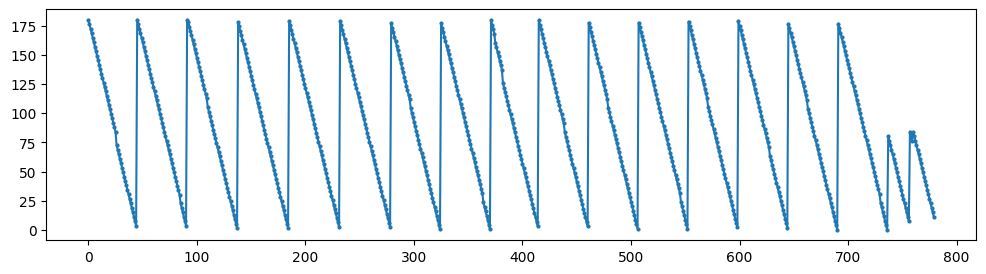

In [14]:
# Import compression utilities
import torch
import cv2
from tqdm.auto import tqdm
import pandas as pd

NUM_FRAMES = 956526  # First NUM_FRAMES images

# Open the H5 file and extract angles from exchange/theta
print("🔍 Extracting angles from exchange/theta dataset...")


with h5py.File(data_path, 'r') as f:
    # Check if exchange/theta exists
    if ('exchange' in f and 'theta' in f['exchange']) or ('theta' in f):
        theta_dataset = f['exchange/theta'] if 'exchange/theta' in f else f['theta']
        print(f"✅ Found exchange/theta dataset")
        print(f"   Shape: {theta_dataset.shape}")
        print(f"   Data type: {theta_dataset.dtype}")
        print(f"   Size: {theta_dataset.size:,} elements")
        
        # Load the theta data and convert to torch tensor
        theta_data = theta_dataset[...]
        angles = torch.from_numpy(theta_data).float()

        differences = angles.roll(-1) - angles
        mask = differences > 20
        print("mask", mask)

        # normalizing angles
        angles = angles % 180
        
        print(f"🎯 Created angles tensor:")
        print(f"   Shape: {angles.shape}")
        print(f"   Data type: {angles.dtype}")
        print(f"   Range: [{angles.min():.6f}, {angles.max():.6f}]")
        print(f"   First 10 angles: {angles[:10].tolist()}")
        print(f"   Last 10 angles: {angles[-10:].tolist()}")
        
        # Additional statistics
        print(f"\n📊 Angle Statistics:")
        print(f"   Mean: {angles.mean():.6f}")
        print(f"   Std: {angles.std():.6f}")
        print(f"   Min: {angles.min():.6f}")
        print(f"   Max: {angles.max():.6f}")
        print(f"   Range: {angles.max() - angles.min():.6f}")
        
        print(f"\n✅ Angles tensor created successfully!")
        print(angles)
        plt.figure(figsize=(12, 3))
        plt.plot(angles[:969].numpy(), marker='o', linestyle='-', markersize=2)
    else:
        print("❌ exchange/theta dataset not found")
        if 'exchange' not in f:
            print("   'exchange' group does not exist")
        else:
            print(f"   Available datasets in exchange: {list(f['exchange'].keys())}")
        angles = None
        

In [6]:
# import os

# import matplotlib.pyplot as plt
# import torch.nn.functional as F
# import wandb
# from tqdm.auto import tqdm
# import glob
# import subprocess
# from pathlib import Path
# from argparse import ArgumentParser
# import random

# from sdate.datasets.tiff_dataset import TiffDataset
# from sdate.datasets.tiff_tomogram_dataset import TIFFDataset
# from sdate.models.small_CNN import CNN_small
# from sdate.training.train_step_prediction import get_resnet, top_k_accuracy
# from pytorch_base.stats_tracker import StatsTracker
# import lovely_tensors as lt
# lt.monkey_patch()
# import torch
# from diffusers import DDPMScheduler
# from sdate.streaming.stream_step_prediction import list_subfolders
# # data_path="/Users/lfbarba/GitHub/deep-anomaly-detection/data/p16739/043_AG10_C1mm_0s/timesteps"
# # data_path="/Users/lfbarba/GitHub/deep-anomaly-detection/data/p16739/149_ASM_SP_1ktps/timesteps"
# # data_path="/Users/lfbarba/GitHub/deep-anomaly-detection/data/p16739/090_ASC_thixo_650tps/timesteps"
# # data_path="/Users/lfbarba/GitHub/deep-anomaly-detection/data/p16739/212_Wunderkerze2/timesteps"
# data_path = "/Users/lfbarba/GitHub/deep-anomaly-detection/data/downsampled_cordierite/"
# # 
# # data_path="/Users/lfbarba/GitHub/deep-anomaly-detection/data/deformed_bubbles_synthetic_brownian"
# # clip_range = [100, 250]
# # clip_range = [20000, 40000]
# clip_range = None

# subfolders = list_subfolders(data_path)
# subfolders = [x for x in sorted(subfolders)]
# print("subfolders", len(subfolders))

# from diffusers import DDPMScheduler
# from pytorch_base.stats_tracker import StatsTracker

# noise_scheduler = DDPMScheduler(num_train_timesteps=1000)
# im_size = 512
# datasetFirst = TiffDataset(subfolders[0], rescale=im_size, clip_range=clip_range)

# mean_tracker = StatsTracker("Mean", {"mean", "std"})
# for img in datasetFirst:
#     mean_tracker.add({"mean": img.mean(), "std":img.std()}, 1)

# img_first = datasetFirst[-1].squeeze()
# img_first -= mean_tracker.get_mean("mean")
# img_first /= mean_tracker.get_mean("std")

# timesteps = torch.tensor([100]).int()
# noisy_img = noise_scheduler.add_noise(img_first, torch.randn_like(img_first), timesteps)

# fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10,5))
# ax1.imshow(img_first, cmap='gray')
# ax2.imshow(noisy_img, cmap='gray')
# img_first

In [7]:
# import numpy as np
# min_val = float('inf')
# max_val = float('-inf')

# iterator = range(len(datasetFirst))

# for i in tqdm(iterator):
#     x = datasetFirst[i]
#     min_val = min(min_val, x.min())
#     max_val = max(max_val, x.max())

# print("REAL MAX VAL:", max_val)
# # max_val = max(max_val, 2**10) # restrict to 10-bit precision
# # max_val = 608

# print("USING MAX VAL:", max_val)

# print(f"Loaded data shape: {datasetFirst[0].shape}")
# print(f"Data type: {datasetFirst[0].dtype}")
# print("Min value:", min_val)
# print("Max value:", max_val)

# # Convert to tensor and normalize
# video_normalized = torch.zeros(len(datasetFirst), datasetFirst[0].shape[1], datasetFirst[0].shape[2])
# video_tensor_original = torch.zeros(len(datasetFirst), datasetFirst[0].shape[1], datasetFirst[0].shape[2]).to(torch.uint16 if datasetFirst[0].dtype == np.uint16 else torch.float32)

# for i, j in enumerate(tqdm(range(len(datasetFirst)))):
#     video_normalized[i] = (datasetFirst[j].to(torch.float32) - min_val) / (max_val - min_val)
#     video_tensor_original[i] = datasetFirst[j].to(video_tensor_original.dtype)

# video_normalized = video_normalized.clip(0, 1)
# video_tensor_original = video_tensor_original


# print(f"\nOriginal video tensor:")
# print(f"  Shape: {video_tensor_original.shape}")
# print(f"  Range: [{min_val}, {max_val}]")
# print(f"  Data type: {video_tensor_original.dtype}")

# print(f"\nNormalized video tensor:")
# print(f"  Shape: {video_normalized.shape}")
# print(f"  Range: [{video_normalized.min():.6f}, {video_normalized.max():.6f}]")
# print(f"  Data type: {video_normalized.dtype}")

In [15]:
# Load and prepare the first 4000 images for compression analysis
print(f"📊 Loading first {NUM_FRAMES} images from exchange data...")

with h5py.File(data_path, 'r') as f:
    # Check the actual dataset shape
    dataset_name = 'exchange/data' if 'exchange/data' in f else 'stack_object_i'
    dataset_shape = f[dataset_name].shape
    print(f"Full dataset shape: {dataset_shape}")
    
    if dataset_shape[0] < NUM_FRAMES:
        NUM_FRAMES = dataset_shape[0]
        print(f"⚠️  Dataset has only {dataset_shape[0]} frames. Using all available frames.")
    
    # Load the first NUM_FRAMES images
    print(f"Loading first {NUM_FRAMES} frames...")
    raw_data = f[dataset_name]
    # iterate over raw_data to get min and max values
    min_val = float('inf')
    max_val = float('-inf')

    iterator = range(0, NUM_FRAMES)

    for i in tqdm(iterator):
        x = raw_data[i]
        min_val = min(min_val, x.min())
        max_val = max(max_val, x.max())
    
    print("REAL MAX VAL:", max_val)
    # max_val = max(max_val, 2**10) # restrict to 10-bit precision
    # max_val = 608

    print("USING MAX VAL:", max_val)

    print(f"Loaded data shape: {raw_data.shape}")
    print(f"Data type: {raw_data.dtype}")
    print("Min value:", min_val)
    print("Max value:", max_val)

    # Convert to tensor and normalize
    video_normalized = torch.zeros(len(iterator), raw_data.shape[1], raw_data.shape[2])
    video_tensor_original = torch.zeros(len(iterator), raw_data.shape[1], raw_data.shape[2]).to(torch.uint16 if raw_data.dtype == np.uint16 else torch.float32)

    for i, j in enumerate(tqdm(iterator)):
        video_normalized[i] = (torch.from_numpy(f[dataset_name][j]).to(torch.float32) - min_val) / (max_val - min_val)
        video_tensor_original[i] = torch.from_numpy(f[dataset_name][j]).to(video_tensor_original.dtype)

video_normalized = video_normalized.clip(0, 1)
video_tensor_original = video_tensor_original


print(f"\nOriginal video tensor:")
print(f"  Shape: {video_tensor_original.shape}")
print(f"  Range: [{min_val}, {max_val}]")
print(f"  Data type: {video_tensor_original.dtype}")

print(f"\nNormalized video tensor:")
print(f"  Shape: {video_normalized.shape}")
print(f"  Range: [{video_normalized.min():.6f}, {video_normalized.max():.6f}]")
print(f"  Data type: {video_normalized.dtype}")

📊 Loading first 956526 images from exchange data...
Full dataset shape: (780, 1426, 1025)
⚠️  Dataset has only 780 frames. Using all available frames.
Loading first 780 frames...


  0%|          | 0/780 [00:00<?, ?it/s]

REAL MAX VAL: 2.3208094
USING MAX VAL: 2.3208094
Loaded data shape: (780, 1426, 1025)
Data type: float32
Min value: -2.241353
Max value: 2.3208094


  0%|          | 0/780 [00:00<?, ?it/s]


Original video tensor:
  Shape: torch.Size([780, 1426, 1025])
  Range: [-2.2413530349731445, 2.3208093643188477]
  Data type: torch.float32

Normalized video tensor:
  Shape: torch.Size([780, 1426, 1025])
  Range: [0.000000, 1.000000]
  Data type: torch.float32


In [9]:
# video_normalized[0] = video_normalized[1]
# video_tensor_original[0] = video_tensor_original[1]


📊 Computing MSE differences between frames and first frame...
Computing MSE for every 1th frame...


Computing MSE: 100%|██████████| 780/780 [00:01<00:00, 737.95it/s] 


✅ Computed MSE for 780 frames


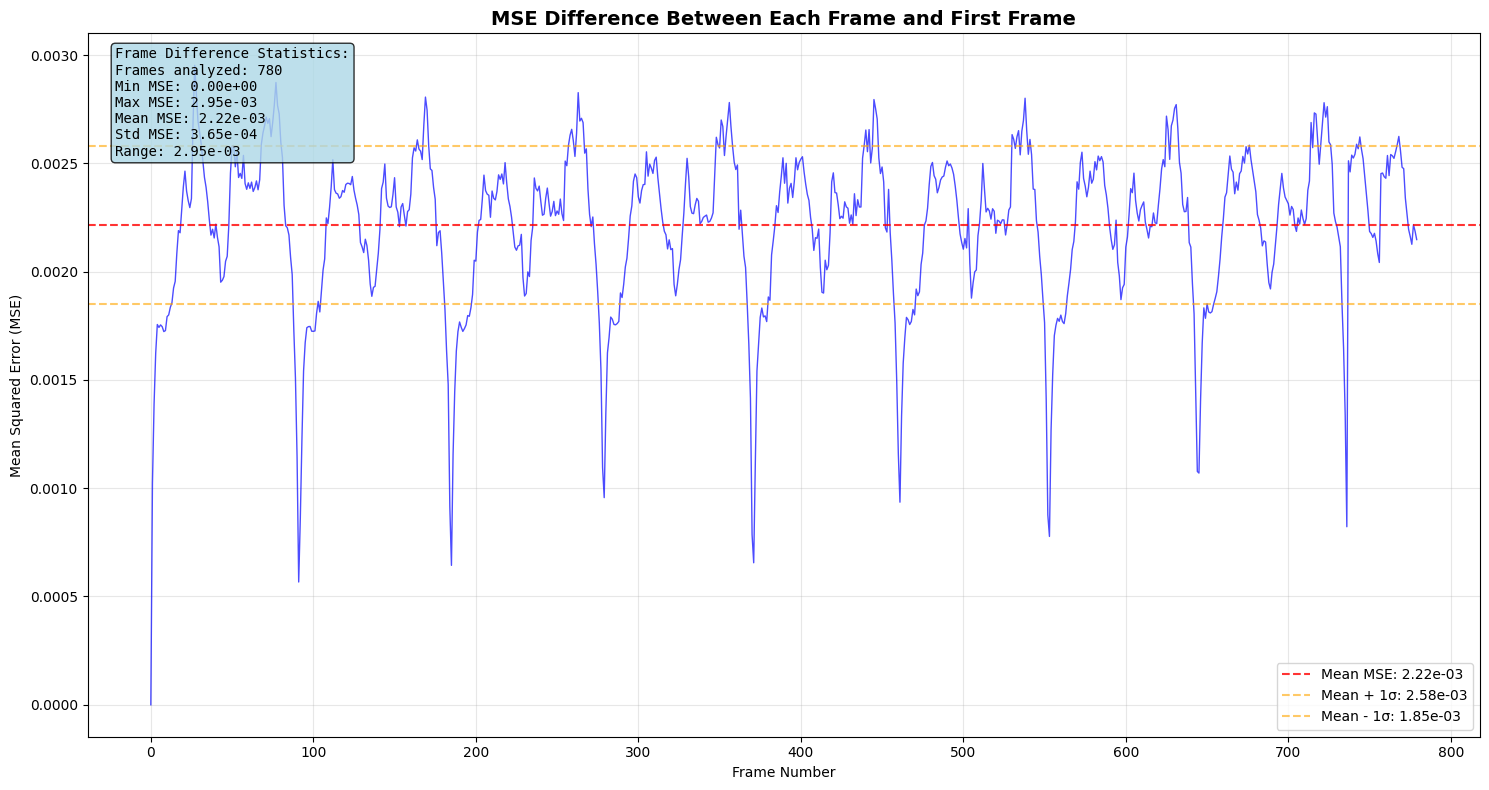


📈 MSE Analysis Summary:
   Minimum MSE: 0.00e+00
   Maximum MSE: 2.95e-03
   Mean MSE: 2.22e-03
   Standard Deviation: 3.65e-04
   Dynamic Range: infx


/var/folders/tz/dk16058s17q23bj28chlys680000gn/T/ipykernel_92397/3582159837.py:65: RuntimeWarning: divide by zero encountered in scalar divide
  print(f"   Dynamic Range: {max_mse/min_mse:.1f}x")


In [16]:
from tqdm import tqdm
# Compute MSE differences between each frame and the first frame
print("📊 Computing MSE differences between frames and first frame...")

# Get the first frame as reference
reference_frame = video_normalized[0].float()

# Compute MSE for each frame compared to the first frame
mse_differences = []
frame_indices = []

# Sample frames for computation (every 100th frame for speed, or all if small dataset)
step_size = 1
print(f"Computing MSE for every {step_size}th frame...")

for i in tqdm(range(0, len(video_normalized), step_size), desc="Computing MSE"):
    current_frame = video_normalized[i].float()
    mse = torch.mean((current_frame - reference_frame) ** 2).item()
    mse_differences.append(mse)
    frame_indices.append(i)

print(f"✅ Computed MSE for {len(mse_differences)} frames")

# Create the plot
plt.figure(figsize=(15, 8))
plt.plot(frame_indices, mse_differences, 'b-', alpha=0.7, linewidth=1)
plt.title('MSE Difference Between Each Frame and First Frame', fontsize=14, fontweight='bold')
plt.xlabel('Frame Number')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True, alpha=0.3)

# Add statistics
mean_mse = np.mean(mse_differences)
std_mse = np.std(mse_differences)
max_mse = np.max(mse_differences)
min_mse = np.min(mse_differences)

plt.axhline(y=mean_mse, color='r', linestyle='--', alpha=0.8, label=f'Mean MSE: {mean_mse:.2e}')
plt.axhline(y=mean_mse + std_mse, color='orange', linestyle='--', alpha=0.6, label=f'Mean + 1σ: {mean_mse + std_mse:.2e}')
plt.axhline(y=mean_mse - std_mse, color='orange', linestyle='--', alpha=0.6, label=f'Mean - 1σ: {mean_mse - std_mse:.2e}')

plt.legend()
plt.tight_layout()

# Add text box with statistics
stats_text = f'''Frame Difference Statistics:
Frames analyzed: {len(mse_differences)}
Min MSE: {min_mse:.2e}
Max MSE: {max_mse:.2e}
Mean MSE: {mean_mse:.2e}
Std MSE: {std_mse:.2e}
Range: {max_mse - min_mse:.2e}'''

plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes, 
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.show()

print(f"\n📈 MSE Analysis Summary:")
print(f"   Minimum MSE: {min_mse:.2e}")
print(f"   Maximum MSE: {max_mse:.2e}")
print(f"   Mean MSE: {mean_mse:.2e}")
print(f"   Standard Deviation: {std_mse:.2e}")
print(f"   Dynamic Range: {max_mse/min_mse:.1f}x")

In [8]:
# # RGB with 3 channels
# from sdate.video_compression import encode_hevc_rgb_10bit , decode_hevc_rgb_10bit
# compressed_video_path = "demo_10b.mov"
# video_grouped = video_normalized.view(-1, 3, video_normalized.shape[-2], video_normalized.shape[-1])
# video_grouped = video_grouped.permute(0, 2, 3, 1)
# encode_hevc_rgb_10bit(video_grouped, compressed_video_path, fps=30, preset_sw="veryslow", cq_hw=100) # 100 is visually lossless, crf_sw=14 is visually lossless
# reconstructed_video = decode_hevc_rgb_10bit(compressed_video_path, device="cpu")
# reconstructed_video = reconstructed_video.permute(0, 3, 1, 2).flatten(0, 1)
# reconstructed_video
# print("reconstructed_video", reconstructed_video)

In [17]:
compressed_video_path = "demo_10b.mov"
encode_hevc_grayscale_10bit(video_normalized, compressed_video_path, fps=30, cq_hw=100) # 100 is visually lossless, crf_sw=14 is visually lossless
reconstructed_video = decode_hevc_grayscale_10bit(compressed_video_path, device="cpu")
print("reconstructed_video", reconstructed_video)

📤  encoding 780 × 1025×1426 frames  (grayscale 10-bit HEVC)
✓ hardware encode succeeded


/Users/lfbarba/GitHub/deep-anomaly-detection/sdate/video_compression/hevc_grayscale.py:194: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:209.)
  vf = torch.from_numpy(v16).to(torch.float32) / 65535.0


reconstructed_video tensor[780, 1426, 1024] n=1138974720 (4.2Gb) x∈[1.526e-05, 0.999] μ=0.475 σ=0.037


In [18]:
# compressed_video_path = "demo_10b.mov"
# encode_hevc_grayscale_10bit(
#     video_normalized, compressed_video_path, 
#     fps=30, preset_sw="veryslow", cq_hw=100,
#     crf_sw=10, tune_grain=True, force_software=True,
#     threads=0, frame_threads=2, pools="8,2",
#     extra_x265="pmode=1:pme=1:aq-mode=3:aq-strength=0.8:rd=4"
# ) # 100 is visually lossless, crf_sw=14 is visually lossless
# reconstructed_video = decode_hevc_grayscale_10bit(compressed_video_path, device="cpu")
# print("reconstructed_video", reconstructed_video)

In [19]:
# Load the compressed video for comparison
print("🎬 Loading Compressed Video for Quality Analysis")
print("=" * 60)

try:
    # Load the compressed video
    # Check if file exists and get size
    if os.path.exists(compressed_video_path):
        compressed_file_size = os.path.getsize(compressed_video_path)
        print(f"📁 Compressed file found: {compressed_video_path}")
        print(f"📏 Compressed file size: {compressed_file_size / 1e6:.2f} MB")
    else:
        raise FileNotFoundError(f"Compressed video file not found: {compressed_video_path}")
    
    # Calculate original data size
    original_tensor_size = video_tensor_original.numel() * video_tensor_original.element_size()

    print(f"\n📊 Size Comparison:")
    print(f"   Original tensor size: {original_tensor_size / 1e6:.2f} MB")
    print(f"   Compressed file size: {compressed_file_size / 1e6:.2f} MB")
    
    # Calculate compression ratio
    compression_ratio = original_tensor_size / compressed_file_size
    space_savings = (1 - compressed_file_size / original_tensor_size) * 100
    
    print(f"   Compression ratio: {compression_ratio:.1f}:1")
    print(f"   Space savings: {space_savings:.1f}%")
    
    print(f"\n✅ Video loaded successfully for comparison")
    
except Exception as e:
    print(f"❌ Error loading compressed video: {e}")
    print("   Make sure the video was encoded successfully")
    reconstructed_video = None

🎬 Loading Compressed Video for Quality Analysis
📁 Compressed file found: demo_10b.mov
📏 Compressed file size: 506.60 MB

📊 Size Comparison:
   Original tensor size: 4560.35 MB
   Compressed file size: 506.60 MB
   Compression ratio: 9.0:1
   Space savings: 88.9%

✅ Video loaded successfully for comparison


In [20]:
# Calculate Quality Metrics using Centralized Function (with 5-pixel crop)
if reconstructed_video is not None:
    print("📈 Calculating Quality Metrics with Artifact Avoidance")
    print("=" * 60)
    
    # Ensure both tensors have the same dimensions for comparison
    min_frames = min(video_tensor_original.shape[0], reconstructed_video.shape[0])
    min_height = min(video_tensor_original.shape[1], reconstructed_video.shape[1])
    min_width = min(video_tensor_original.shape[2], reconstructed_video.shape[2])
    
    # Crop both videos to same size
    original_crop = video_normalized
    reconstructed_crop = reconstructed_video
    
    print(f"Comparing tensors with shape: {original_crop.shape}")
    
    # Normalize original to [0, 1] if needed
    if original_crop.max() > 1.0:
        original_normalized = (original_crop - original_crop.min()) / (original_crop.max() - original_crop.min())
    else:
        original_normalized = original_crop
    
    # Use centralized quality metrics function with 5-pixel crop
    print(f"🔍 Using centralized quality metrics with 5-pixel edge crop...")
    metrics = calculate_quality_metrics(original_normalized, reconstructed_crop, crop_pixels=5)
    
    # Extract results
    psnr_value = metrics['psnr']
    ssim_value = metrics['ssim']
    mse = metrics['mse']
    cropped_shape = metrics['cropped_shape']
    
    print(f"🎯 PSNR: {psnr_value:.2f} dB (cropped region: {cropped_shape})")
    print(f"🎯 SSIM: {ssim_value:.6f}")
    print(f"📊 MSE: {mse:.2e}")
    
    # Calculate per-frame statistics using centralized function
    print(f"\n📊 Per-Frame Statistics (5-pixel crop applied):")
    frame_psnrs = []
    frame_ssims = []
    
    for i in range(min(10, min_frames)):  # Sample first 10 frames
        frame_metrics = calculate_quality_metrics(
            original_normalized[i:i+1], 
            reconstructed_crop[i:i+1], 
            crop_pixels=5
        )
        frame_psnrs.append(frame_metrics['psnr'])
        frame_ssims.append(frame_metrics['ssim'])
    
    # Filter out any infinite values for statistics
    finite_psnrs = [p for p in frame_psnrs if p != float('inf')]
    
    if finite_psnrs:
        print(f"   Average PSNR (first 10 frames): {np.mean(finite_psnrs):.2f} dB")
        print(f"   Average SSIM (first 10 frames): {np.mean(frame_ssims):.6f}")
        print(f"   PSNR range: [{min(finite_psnrs):.2f}, {max(finite_psnrs):.2f}] dB")
        print(f"   SSIM range: [{min(frame_ssims):.6f}, {max(frame_ssims):.6f}]")
    else:
        print(f"   Average PSNR (first 10 frames): {np.mean(frame_psnrs):.2f} dB")
        print(f"   Average SSIM (first 10 frames): {np.mean(frame_ssims):.6f}")
    
    # Quality assessment
    print(f"\n🏆 Quality Assessment:")
    if psnr_value > 40:
        quality_rating = "Excellent"
    elif psnr_value > 30:
        quality_rating = "Very Good"
    elif psnr_value > 25:
        quality_rating = "Good"
    elif psnr_value > 20:
        quality_rating = "Fair"
    else:
        quality_rating = "Poor"
    
    print(f"   Overall Quality: {quality_rating}")
    print(f"   SSIM Quality: {'Excellent' if ssim_value > 0.95 else 'Very Good' if ssim_value > 0.9 else 'Good' if ssim_value > 0.8 else 'Fair'}")
    
    # Additional information about cropping
    original_pixels = min_frames * min_height * min_width
    cropped_pixels = cropped_shape[0] * cropped_shape[1] * cropped_shape[2] if len(cropped_shape) == 3 else cropped_shape[0] * cropped_shape[1]
    edge_pixels_removed = original_pixels - cropped_pixels
    
    print(f"\n💡 Artifact Avoidance Info:")
    print(f"   Edge pixels removed: {edge_pixels_removed:,} ({edge_pixels_removed/original_pixels*100:.1f}%)")
    print(f"   Analysis region: {cropped_shape}")
    print(f"   Crop applied: 5 pixels from each edge")
    
else:
    print("⚠️  Cannot calculate quality metrics - compressed video not loaded")

📈 Calculating Quality Metrics with Artifact Avoidance
Comparing tensors with shape: torch.Size([780, 1426, 1025])
🔍 Using centralized quality metrics with 5-pixel edge crop...


RuntimeError: The size of tensor a (1015) must match the size of tensor b (1014) at non-singleton dimension 2

🎨 Creating Visual Comparison


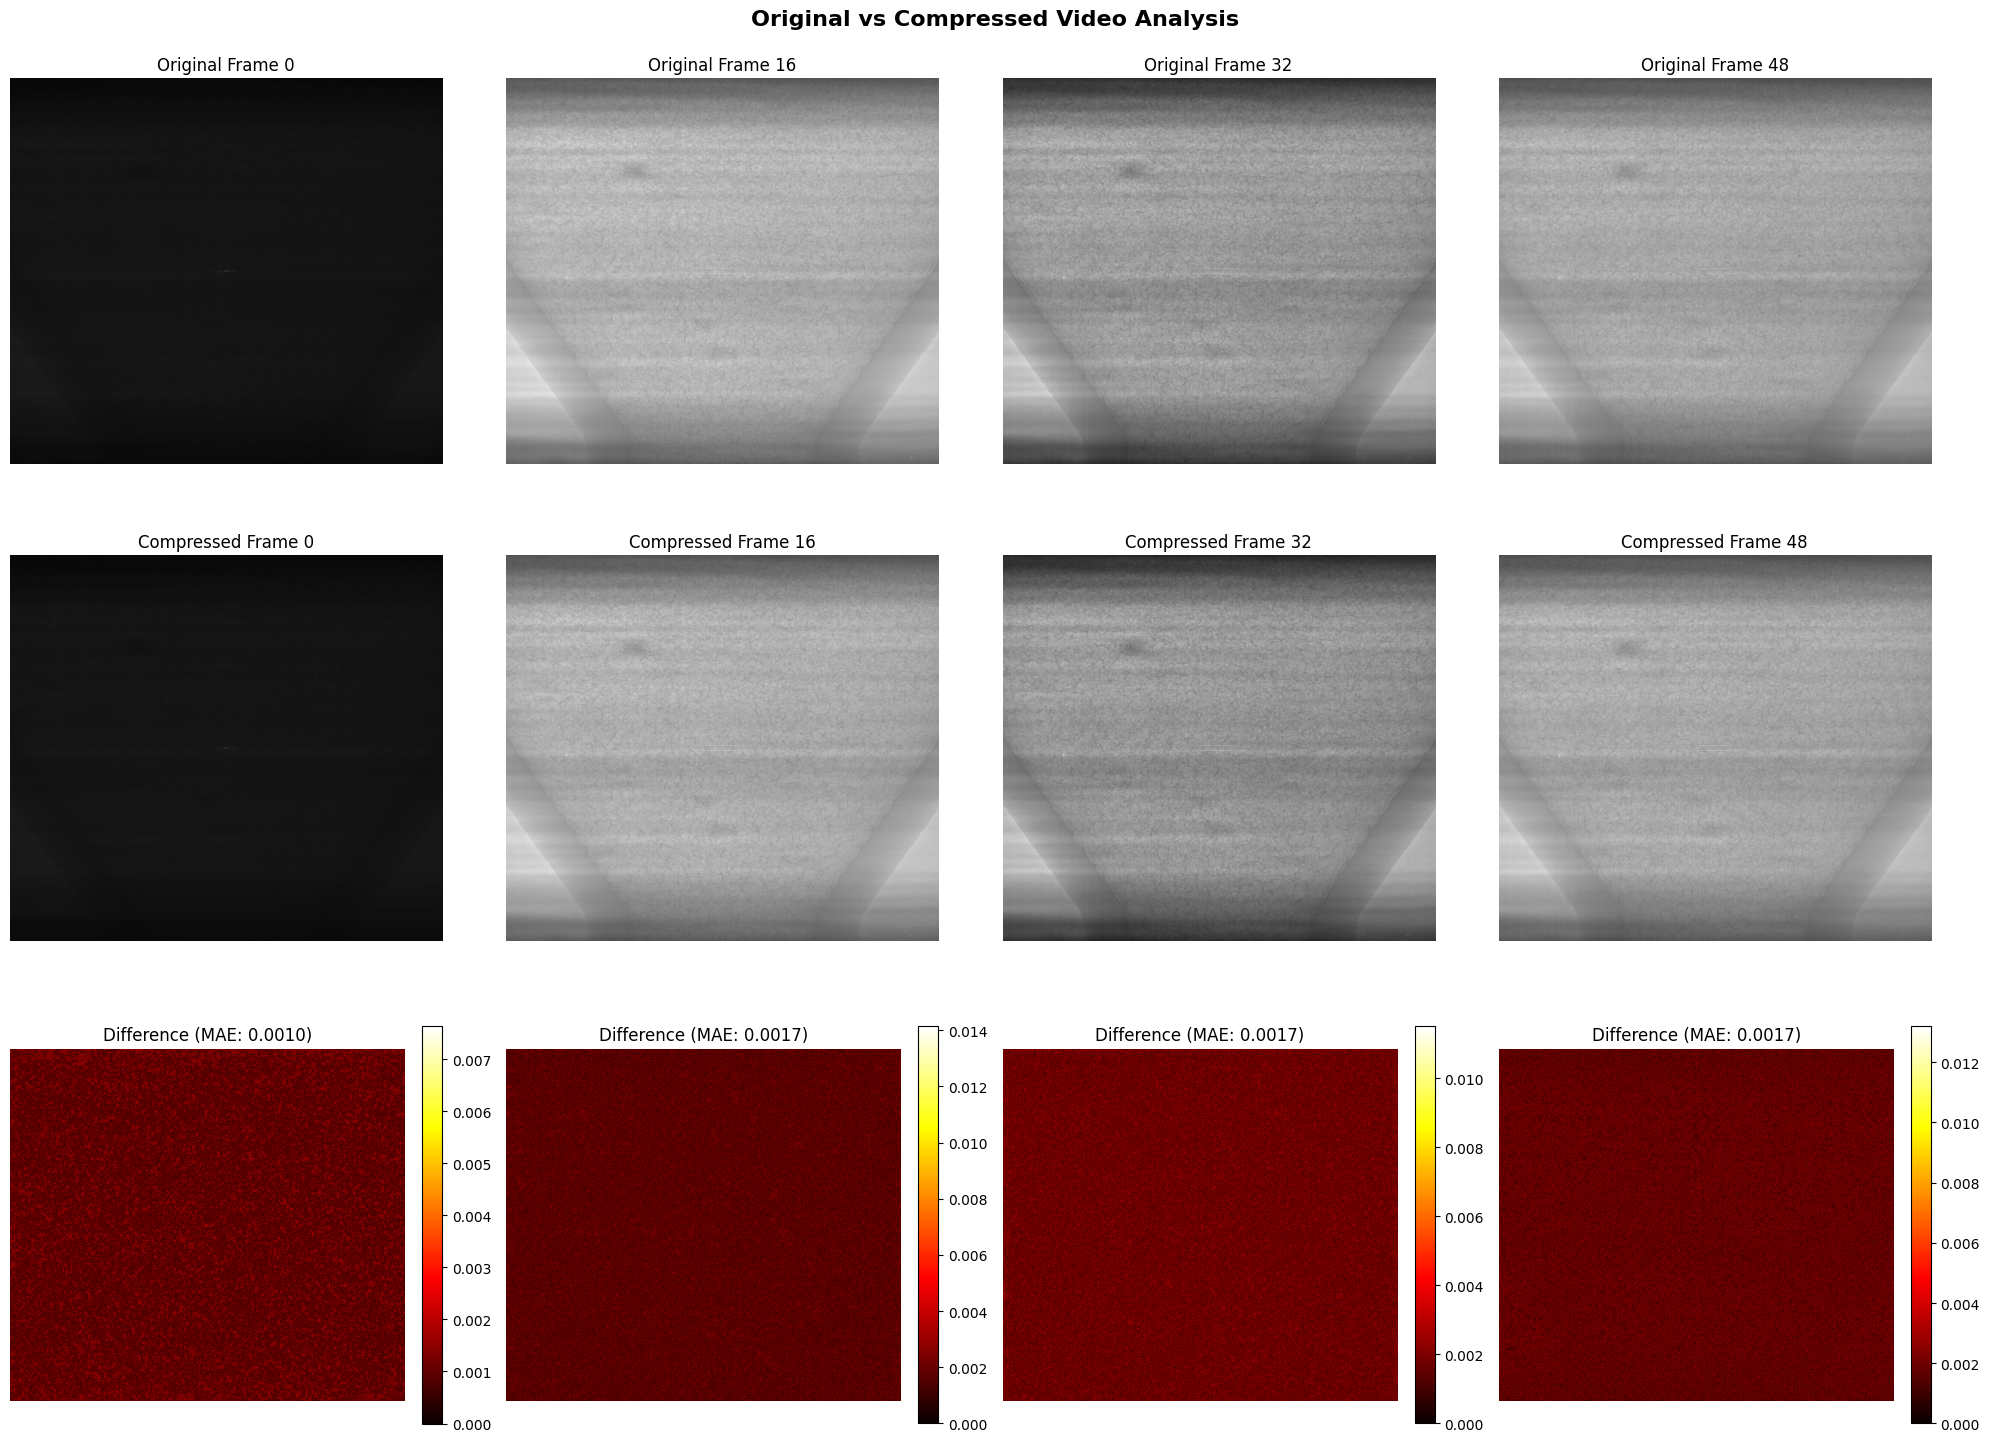

100%|██████████| 65/65 [00:00<00:00, 125.53it/s]


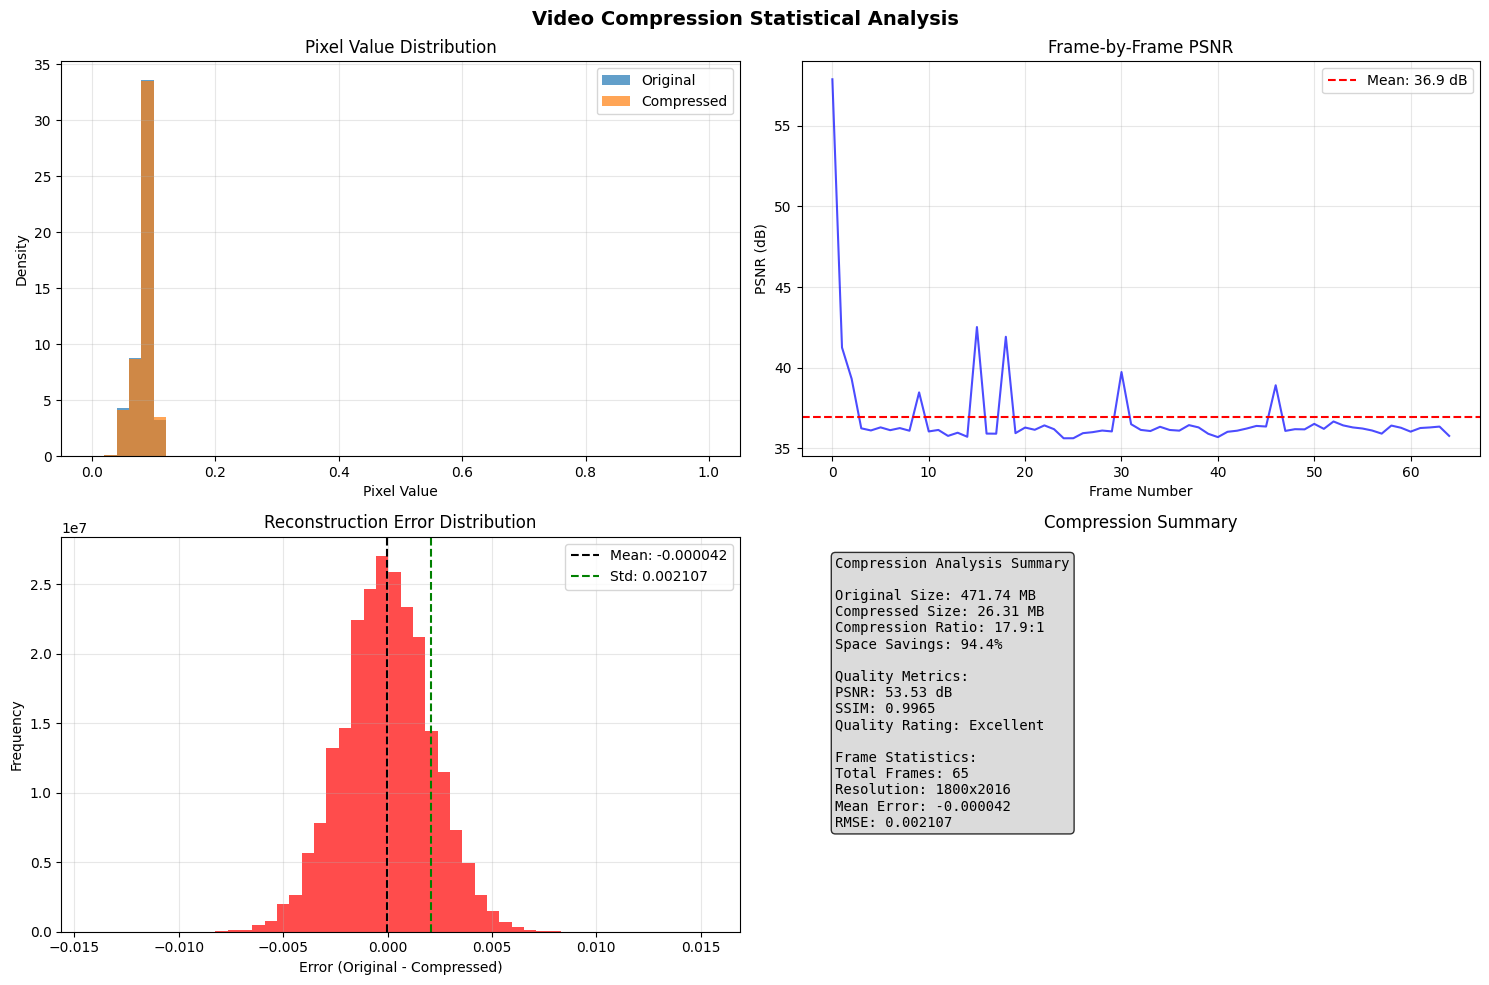

✅ Visual comparison completed


In [21]:
# Visual Comparison and Analysis
if reconstructed_video is not None:
    print("🎨 Creating Visual Comparison")
    print("=" * 40)
    
    # Create comprehensive comparison plots
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    fig.suptitle('Original vs Compressed Video Analysis', fontsize=16, fontweight='bold')
    
    # Select frames for comparison (first, middle, last few)
    comparison_frames = [0, min_frames//4, min_frames//2, 3*min_frames//4, min_frames-1]
    comparison_frames = comparison_frames[:4]  # Limit to 4 frames
    
    for i, frame_idx in enumerate(comparison_frames):
        # Original frame
        axes[0, i].imshow(original_normalized[frame_idx][5:-5, 5:-5], cmap='gray')
        axes[0, i].set_title(f'Original Frame {frame_idx}')
        axes[0, i].axis('off')
        
        # Reconstructed frame  
        axes[1, i].imshow(reconstructed_crop[frame_idx][5:-5, 5:-5], cmap='gray')
        axes[1, i].set_title(f'Compressed Frame {frame_idx}')
        axes[1, i].axis('off')
        
        # Difference map
        diff = torch.abs(original_normalized[frame_idx][5:-5, 5:-5] - reconstructed_crop[frame_idx][5:-5, 5:-5])
        im = axes[2, i].imshow(diff, cmap='hot', vmin=0, vmax=diff.max())
        axes[2, i].set_title(f'Difference (MAE: {torch.mean(diff):.4f})')
        axes[2, i].axis('off')
        
        # Add colorbar for difference maps
        plt.colorbar(im, ax=axes[2, i], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()
    
    # Statistical Analysis Plots
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Video Compression Statistical Analysis', fontsize=14, fontweight='bold')
    
    # Histogram comparison
    axes[0, 0].hist(original_normalized.flatten().numpy(), bins=50, alpha=0.7, label='Original', density=True)
    axes[0, 0].hist(reconstructed_crop.flatten().numpy(), bins=50, alpha=0.7, label='Compressed', density=True)
    axes[0, 0].set_title('Pixel Value Distribution')
    axes[0, 0].set_xlabel('Pixel Value')
    axes[0, 0].set_ylabel('Density')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Frame-by-frame PSNR
    frame_psnrs_all = []
    skip_frames = 500
    for i in tqdm(range(0, min_frames, max(1, min_frames//skip_frames))):  # Sample frames for speed
        frame_psnr = calculate_quality_metrics(original_normalized[i:i+1], reconstructed_crop[i:i+1])['psnr']
        frame_psnrs_all.append(frame_psnr)
    
    sample_frames = list(range(0, min_frames, max(1, min_frames//skip_frames)))[:len(frame_psnrs_all)]
    axes[0, 1].plot(sample_frames, frame_psnrs_all, 'b-', alpha=0.7)
    axes[0, 1].set_title('Frame-by-Frame PSNR')
    axes[0, 1].set_xlabel('Frame Number')
    axes[0, 1].set_ylabel('PSNR (dB)')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].axhline(y=np.mean(frame_psnrs_all), color='r', linestyle='--', label=f'Mean: {np.mean(frame_psnrs_all):.1f} dB')
    axes[0, 1].legend()
    
    # Error distribution
    error = (original_normalized - reconstructed_crop).flatten()
    axes[1, 0].hist(error.numpy(), bins=50, alpha=0.7, color='red')
    axes[1, 0].set_title('Reconstruction Error Distribution')
    axes[1, 0].set_xlabel('Error (Original - Compressed)')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].axvline(x=torch.mean(error).item(), color='black', linestyle='--', label=f'Mean: {torch.mean(error):.6f}')
    axes[1, 0].axvline(x=torch.std(error).item(), color='green', linestyle='--', label=f'Std: {torch.std(error):.6f}')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Compression metrics summary
    metrics_text = f'''Compression Analysis Summary
    
Original Size: {original_tensor_size / 1e6:.2f} MB
Compressed Size: {compressed_file_size / 1e6:.2f} MB
Compression Ratio: {compression_ratio:.1f}:1
Space Savings: {space_savings:.1f}%

Quality Metrics:
PSNR: {psnr_value:.2f} dB
SSIM: {ssim_value:.4f}
Quality Rating: {quality_rating}

Frame Statistics:
Total Frames: {min_frames}
Resolution: {min_height}x{min_width}
Mean Error: {torch.mean(error):.6f}
RMSE: {torch.sqrt(torch.mean(error**2)):.6f}'''
    
    axes[1, 1].text(0.05, 0.95, metrics_text, transform=axes[1, 1].transAxes, 
                    fontsize=10, verticalalignment='top', fontfamily='monospace',
                    bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    axes[1, 1].set_xlim(0, 1)
    axes[1, 1].set_ylim(0, 1)
    axes[1, 1].axis('off')
    axes[1, 1].set_title('Compression Summary')
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Visual comparison completed")
    
else:
    print("⚠️  Cannot create visual comparison - compressed video not loaded")

In [22]:
# Comprehensive Comparison Summary
if reconstructed_video is not None:
    print("📋 Comprehensive Comparison Summary")
    print("=" * 60)
    
    # Create summary table
    import pandas as pd
    
    # Calculate additional metrics
    mae = torch.mean(torch.abs(original_normalized - reconstructed_crop)).item()
    rmse = torch.sqrt(torch.mean((original_normalized - reconstructed_crop) ** 2)).item()
    max_error = torch.max(torch.abs(original_normalized - reconstructed_crop)).item()
    
    # Data usage efficiency
    bits_per_pixel_original = (original_tensor_size * 8) / (min_frames * min_height * min_width)
    bits_per_pixel_compressed = (compressed_file_size * 8) / (min_frames * min_height * min_width)
    
    summary_data = {
        'Metric': [
            'Original Size (MB)',
            'Compressed Size (MB)', 
            'Compression Ratio',
            'Space Savings (%)',
            'Bits per Pixel (Original)',
            'Bits per Pixel (Compressed)',
            '',  # Separator
            'PSNR (dB)',
            'SSIM',
            'Mean Absolute Error',
            'Root Mean Square Error',
            'Maximum Error',
            'Quality Rating'
        ],
        'Value': [
            f'{original_tensor_size / 1e6:.2f}',
            f'{compressed_file_size / 1e6:.2f}',
            f'{compression_ratio:.1f}:1',
            f'{space_savings:.1f}%',
            f'{bits_per_pixel_original:.2f}',
            f'{bits_per_pixel_compressed:.2f}',
            '',  # Separator
            f'{psnr_value:.2f}',
            f'{ssim_value:.4f}',
            f'{mae:.6f}',
            f'{rmse:.6f}',
            f'{max_error:.6f}',
            quality_rating
        ]
    }
    
    df_summary = pd.DataFrame(summary_data)
    print(df_summary.to_string(index=False, justify='left'))
    
    # Performance evaluation
    print(f"\n🎯 Performance Evaluation:")
    print(f"   Compression Efficiency: {'Excellent' if compression_ratio > 50 else 'Very Good' if compression_ratio > 20 else 'Good' if compression_ratio > 10 else 'Moderate'}")
    print(f"   Quality Preservation: {'Excellent' if psnr_value > 40 and ssim_value > 0.95 else 'Very Good' if psnr_value > 30 and ssim_value > 0.9 else 'Good' if psnr_value > 25 else 'Fair'}")
    
    # Recommendations
    print(f"\n💡 Recommendations:")
    if compression_ratio > 20 and psnr_value > 30:
        print("   ✅ Excellent compression with high quality preservation")
        print("   ✅ Suitable for archival and analysis purposes")
    elif compression_ratio > 10 and psnr_value > 25:
        print("   ✅ Good compression with acceptable quality")
        print("   ✅ Suitable for most analysis tasks")
    elif psnr_value < 25:
        print("   ⚠️  Quality may be insufficient for detailed analysis")
        print("   💡 Consider using higher quality settings (lower CRF)")
    elif compression_ratio < 5:
        print("   ⚠️  Low compression efficiency")
        print("   💡 Consider using more aggressive compression settings")
    
    print(f"\n✅ Comprehensive analysis completed!")
    print(f"🎬 The H.265 10-bit compression achieved {compression_ratio:.1f}:1 compression")
    print(f"📊 with {psnr_value:.1f} dB PSNR and {ssim_value:.3f} SSIM quality metrics")
    
else:
    print("⚠️  Cannot create summary - compressed video not loaded")

📋 Comprehensive Comparison Summary
Metric                      Value    
         Original Size (MB)    471.74
       Compressed Size (MB)     26.31
          Compression Ratio    17.9:1
          Space Savings (%)     94.4%
  Bits per Pixel (Original)     16.00
Bits per Pixel (Compressed)      0.89
                                     
                  PSNR (dB)     53.53
                       SSIM    0.9965
        Mean Absolute Error  0.001673
     Root Mean Square Error  0.002107
              Maximum Error  0.015398
             Quality Rating Excellent

🎯 Performance Evaluation:
   Compression Efficiency: Good
   Quality Preservation: Excellent

💡 Recommendations:
   ✅ Good compression with acceptable quality
   ✅ Suitable for most analysis tasks

✅ Comprehensive analysis completed!
🎬 The H.265 10-bit compression achieved 17.9:1 compression
📊 with 53.5 dB PSNR and 0.996 SSIM quality metrics


# 10-bit Quantization Precision Loss Analysis

This section analyzes the quality loss purely from 10-bit quantization, isolating it from video compression effects.

In [26]:
# 10-bit Quantization Precision Loss Analysis
print("🔬 Analyzing Precision Loss from 10-bit Quantization")
print("=" * 60)

# Start with the original raw data (before any processing)
print(f"📊 Original raw data statistics:")
print(f"   Shape: {raw_data.shape}")
print(f"   Data type: {raw_data.dtype}")
print(f"   Range: [{raw_data.min()}, {raw_data.max()}]")

# Step 1: Convert to float32 and normalize (your exact code)
print(f"\n🔄 Step 1: Convert to float32 and normalize...")
original_float = video_normalized
print(f"   After torch conversion: range=[{original_float.min():.2f}, {original_float.max():.2f}]")

print(f"\n🔄 Step 3: Store in 16-bit container...")
video_16bit = (original_float * (2**16 - 1)).to(torch.uint16)
# video_16bit = (reconstructed_crop * (2**16 - 1)).to(torch.uint16)

print(f"   16-bit storage: range=[{video_16bit.float().min().item():.0f}, {video_16bit.float().max().item():.0f}]")
print(f"   16-bit utilization: {video_16bit.float().max().item() / 65535 * 100:.1f}%")

# Step 4: Convert back to original scale for comparison
print(f"\n🔄 Step 4: Convert back to original scale...")
# Reverse the process: 16-bit -> 10-bit -> original scale
video_back_10bit = video_16bit.float() / (2**16 - 1)

print(f"   Reconstructed: range=[{video_back_10bit.min():.2f}, {video_back_10bit.max():.2f}]")
print(f"   Original: range=[{video_normalized.min():.2f}, {video_normalized.max():.2f}]")

# Step 5: Calculate quality metrics (same as used for video compression)
print(f"\n📊 Quality Metrics Analysis:")
print("-" * 40)

# Prepare tensors for comparison (use original float32 data)
reconstructed_for_comparison = video_back_10bit   # Scale back to 16-bit range
original_for_comparison = original_float  # Scale original to 16-bit range
# Calculate MSE
mse_quantization = torch.mean((original_for_comparison - reconstructed_for_comparison) ** 2)
print(f"   Mean Squared Error: {mse_quantization.item():.6e}")

metrics = calculate_quality_metrics(original_for_comparison, reconstructed_for_comparison)
psnr_quantization = metrics['psnr']

ssim_quantization = metrics['ssim']
print(f"   PSNR: {psnr_quantization:.2f} dB")
print(f"   SSIM: {ssim_quantization:.6f}")

# Additional precision metrics
mae_quantization = torch.mean(torch.abs(original_for_comparison - reconstructed_for_comparison))
max_error_quantization = torch.max(torch.abs(original_for_comparison - reconstructed_for_comparison))
rmse_quantization = torch.sqrt(mse_quantization)

print(f"   Mean Absolute Error: {mae_quantization.item():.6e}")
print(f"   Root Mean Square Error: {rmse_quantization.item():.6e}")
print(f"   Maximum Error: {max_error_quantization.item():.6e}")

# Relative error metrics
relative_max_error = max_error_quantization / original_for_comparison.max() * 100
relative_rmse = rmse_quantization / original_for_comparison.max() * 100

print(f"   Relative Max Error: {relative_max_error.item():.4f}%")
print(f"   Relative RMSE: {relative_rmse.item():.4f}%")

# Quality assessment
print(f"\n🎯 Quality Assessment:")
print("-" * 40)

if psnr_quantization > 50:
    quality_rating = "Excellent (>50 dB)"
elif psnr_quantization > 40:
    quality_rating = "Very Good (40-50 dB)"
elif psnr_quantization > 30:
    quality_rating = "Good (30-40 dB)"
elif psnr_quantization > 20:
    quality_rating = "Fair (20-30 dB)"
else:
    quality_rating = "Poor (<20 dB)"

print(f"   PSNR Quality Rating: {quality_rating}")
print(f"   SSIM Quality: {'Excellent' if ssim_quantization > 0.95 else 'Very Good' if ssim_quantization > 0.9 else 'Good' if ssim_quantization > 0.8 else 'Fair'}")

# Bit depth utilization analysis
effective_bits = torch.log2(video_16bit.float().max() - video_16bit.float().min() + 1)
print(f"   Effective bits used: {effective_bits.item():.2f} bits")
print(f"   10-bit efficiency: {effective_bits.item() / 10 * 100:.1f}%")

print(f"\n✅ 10-bit quantization analysis completed!")
print(f"📋 Summary: PSNR = {psnr_quantization:.2f} dB, SSIM = {ssim_quantization:.6f}")

# Store results for comparison with video compression
quantization_psnr = psnr_quantization if psnr_quantization != float('inf') else 999.0
quantization_ssim = ssim_quantization
quantization_mse = mse_quantization.item()

🔬 Analyzing Precision Loss from 10-bit Quantization
📊 Original raw data statistics:
   Shape: (240, 2016, 2016)
   Data type: uint16
   Range: [64, 1688]

🔄 Step 1: Convert to float32 and normalize...
   After torch conversion: range=[0.00, 1.00]

🔄 Step 3: Store in 16-bit container...
   16-bit storage: range=[0, 65535]
   16-bit utilization: 100.0%

🔄 Step 4: Convert back to original scale...
   Reconstructed: range=[0.00, 1.00]
   Original: range=[0.00, 1.00]

📊 Quality Metrics Analysis:
----------------------------------------
   Mean Squared Error: 7.816230e-11
   PSNR: 101.07 dB
   SSIM: 1.000000
   Mean Absolute Error: 7.664527e-06
   Root Mean Square Error: 8.840944e-06
   Maximum Error: 1.524389e-05
   Relative Max Error: 0.0015%
   Relative RMSE: 0.0009%

🎯 Quality Assessment:
----------------------------------------
   PSNR Quality Rating: Excellent (>50 dB)
   SSIM Quality: Excellent
   Effective bits used: 16.00 bits
   10-bit efficiency: 160.0%

✅ 10-bit quantization anal

📊 Visualizing 10-bit Quantization Effects


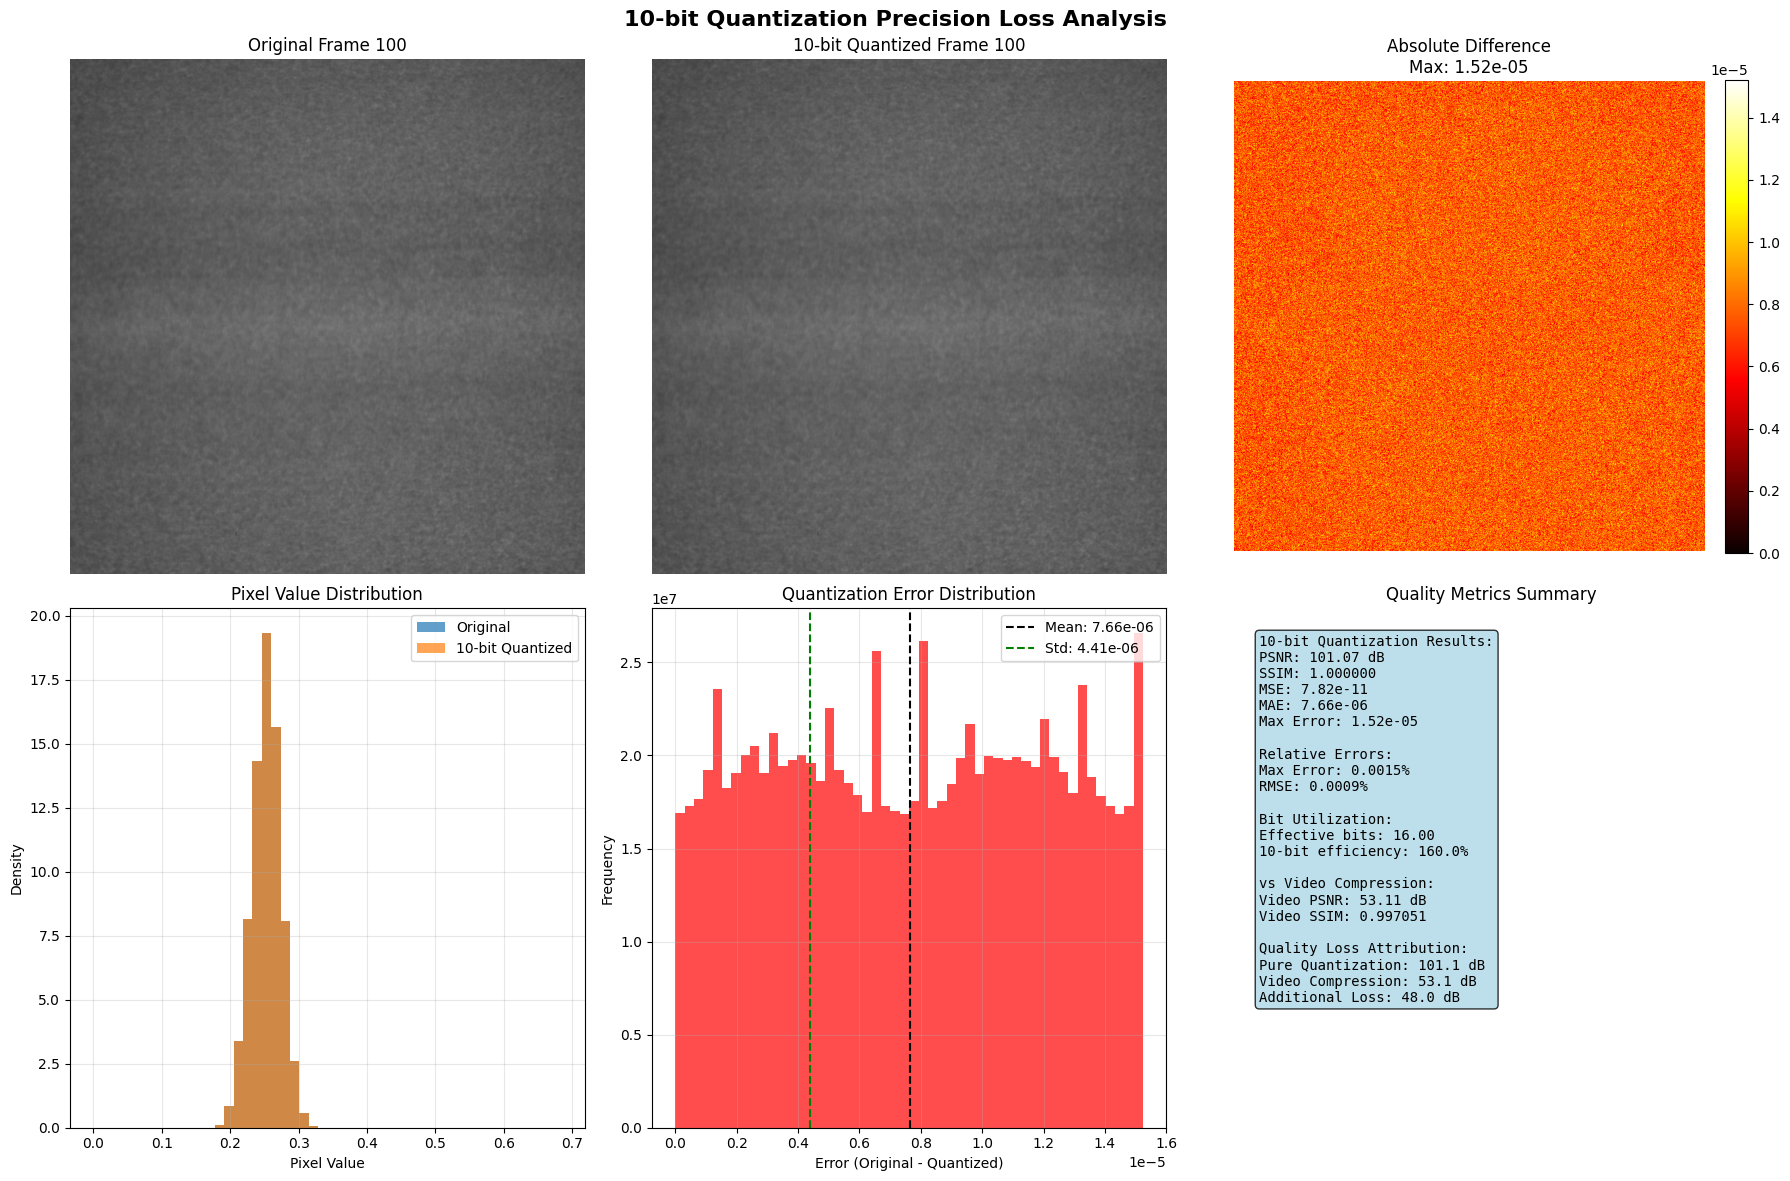


🔍 Frame-by-frame Quality Analysis (every 100th frame):
------------------------------------------------------------
   Frame   0: PSNR =  96.89 dB, SSIM = 1.000000
   Frame 100: PSNR =  97.75 dB, SSIM = 1.000000
   Frame 200: PSNR =  95.77 dB, SSIM = 1.000000

📈 Frame-wise Statistics:
   Mean PSNR: 96.80 ± 0.81 dB
   Mean SSIM: 1.000000 ± 0.000000

🎯 Conclusion:
   10-bit quantization alone achieves 101.1 dB PSNR
   This represents the theoretical upper bound for any 10-bit encoding
   Any additional loss in video compression is due to spatial/temporal compression
   Video compression adds 48.0 dB additional loss
   Compression efficiency: 52.6% of quantization limit

✅ Quantization precision analysis completed!


In [27]:
# Visualize 10-bit Quantization Effects
print("📊 Visualizing 10-bit Quantization Effects")
print("=" * 50)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('10-bit Quantization Precision Loss Analysis', fontsize=16, fontweight='bold')

# Select a representative frame for visualization
frame_idx = min(100, original_for_comparison.shape[0] - 1)
original_frame = original_for_comparison[frame_idx]
quantized_frame = reconstructed_for_comparison[frame_idx]
difference_frame = torch.abs(original_frame - quantized_frame)

# Row 1: Original vs Quantized vs Difference
axes[0, 0].imshow(original_frame.numpy(), cmap='gray')
axes[0, 0].set_title(f'Original Frame {frame_idx}')
axes[0, 0].axis('off')

axes[0, 1].imshow(quantized_frame.numpy(), cmap='gray')
axes[0, 1].set_title(f'10-bit Quantized Frame {frame_idx}')
axes[0, 1].axis('off')

im_diff = axes[0, 2].imshow(difference_frame.numpy(), cmap='hot')
axes[0, 2].set_title(f'Absolute Difference\nMax: {difference_frame.max():.2e}')
axes[0, 2].axis('off')
plt.colorbar(im_diff, ax=axes[0, 2], fraction=0.046, pad=0.04)

# Row 2: Statistical analyses
# Histogram comparison
axes[1, 0].hist(original_frame.flatten().numpy(), bins=50, alpha=0.7, label='Original', density=True)
axes[1, 0].hist(quantized_frame.flatten().numpy(), bins=50, alpha=0.7, label='10-bit Quantized', density=True)
axes[1, 0].set_title('Pixel Value Distribution')
axes[1, 0].set_xlabel('Pixel Value')
axes[1, 0].set_ylabel('Density')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Error histogram
error_flat = (original_for_comparison - reconstructed_for_comparison).flatten()
axes[1, 1].hist(error_flat.numpy(), bins=50, alpha=0.7, color='red')
axes[1, 1].set_title('Quantization Error Distribution')
axes[1, 1].set_xlabel('Error (Original - Quantized)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].axvline(x=torch.mean(error_flat).item(), color='black', linestyle='--', 
                   label=f'Mean: {torch.mean(error_flat).item():.2e}')
axes[1, 1].axvline(x=torch.std(error_flat).item(), color='green', linestyle='--', 
                   label=f'Std: {torch.std(error_flat).item():.2e}')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Comparison with video compression (if available)
comparison_text = f'''10-bit Quantization Results:
PSNR: {quantization_psnr:.2f} dB
SSIM: {quantization_ssim:.6f}
MSE: {quantization_mse:.2e}
MAE: {mae_quantization.item():.2e}
Max Error: {max_error_quantization.item():.2e}

Relative Errors:
Max Error: {relative_max_error.item():.4f}%
RMSE: {relative_rmse.item():.4f}%

Bit Utilization:
Effective bits: {effective_bits.item():.2f}
10-bit efficiency: {effective_bits.item() / 10 * 100:.1f}%'''

# Add video compression comparison if available
if 'psnr_value' in locals() and 'ssim_value' in locals():
    comparison_text += f'''

vs Video Compression:
Video PSNR: {psnr_value:.2f} dB
Video SSIM: {ssim_value:.6f}

Quality Loss Attribution:
Pure Quantization: {quantization_psnr:.1f} dB
Video Compression: {psnr_value:.1f} dB
Additional Loss: {quantization_psnr - psnr_value:.1f} dB'''

axes[1, 2].text(0.05, 0.95, comparison_text, transform=axes[1, 2].transAxes, 
                fontsize=10, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
axes[1, 2].set_xlim(0, 1)
axes[1, 2].set_ylim(0, 1)
axes[1, 2].axis('off')
axes[1, 2].set_title('Quality Metrics Summary')

plt.tight_layout()
plt.show()

# Frame-by-frame analysis for better understanding - using centralized function
print(f"\n🔍 Frame-by-frame Quality Analysis (every 100th frame):")
print("-" * 60)

frame_psnrs_quant = []
frame_ssims_quant = []
sample_frames_quant = []

for i in range(0, min(500, original_for_comparison.shape[0]), 100):
    orig_frame = original_for_comparison[i]
    quant_frame = reconstructed_for_comparison[i]
    
    # Use centralized quality metrics function
    frame_metrics = calculate_quality_metrics(orig_frame, quant_frame)
    
    frame_psnrs_quant.append(frame_metrics['psnr'])
    frame_ssims_quant.append(frame_metrics['ssim'])
    sample_frames_quant.append(i)
    
    print(f"   Frame {i:3d}: PSNR = {frame_metrics['psnr']:6.2f} dB, SSIM = {frame_metrics['ssim']:.6f}")

# Overall statistics
if len(frame_psnrs_quant) > 0:
    mean_frame_psnr = np.mean([p for p in frame_psnrs_quant if p < 900])  # Exclude inf values
    mean_frame_ssim = np.mean(frame_ssims_quant)
    std_frame_psnr = np.std([p for p in frame_psnrs_quant if p < 900])
    std_frame_ssim = np.std(frame_ssims_quant)
    
    print(f"\n📈 Frame-wise Statistics:")
    print(f"   Mean PSNR: {mean_frame_psnr:.2f} ± {std_frame_psnr:.2f} dB")
    print(f"   Mean SSIM: {mean_frame_ssim:.6f} ± {std_frame_ssim:.6f}")

print(f"\n🎯 Conclusion:")
print(f"   10-bit quantization alone achieves {quantization_psnr:.1f} dB PSNR")
print(f"   This represents the theoretical upper bound for any 10-bit encoding")
print(f"   Any additional loss in video compression is due to spatial/temporal compression")

if 'psnr_value' in locals():
    additional_loss = quantization_psnr - psnr_value
    if additional_loss > 0:
        print(f"   Video compression adds {additional_loss:.1f} dB additional loss")
        print(f"   Compression efficiency: {psnr_value/quantization_psnr*100:.1f}% of quantization limit")
    else:
        print(f"   Video compression performs better than pure quantization (unexpected!)")

print(f"\n✅ Quantization precision analysis completed!")

# Save h5 file from compressed video

In [12]:
# Create H5 file from compressed and reconstructed video
print("💾 Creating H5 file from compressed and reconstructed video...")
print("=" * 60)

if 'reconstructed_video' in locals() and reconstructed_video is not None:
    # Create output path based on the input data_path with "compressed" added
    output_h5_path = data_path.parent / (data_path.stem + '_compressed.h5')
    
    print(f"📂 Source H5 file: {data_path}")
    print(f"📂 Output H5 file: {output_h5_path}")
    print(f"📊 Frames to save: {NUM_FRAMES}")
    print(f"📊 Reconstructed video shape: {reconstructed_video.shape}")
    
    # Convert reconstructed video to uint16 to match original format
    # First ensure we have the right data range and type
    if reconstructed_video.max() <= 1.0:
        # Data is in [0, 1] range, scale to uint16
        reconstructed_uint16 = (reconstructed_video * (max_val - min_val) + min_val).to(torch.uint16)
    else:
        # Data might already be in higher range
        reconstructed_uint16 = reconstructed_video.to(torch.uint16)
    
    print(f"📊 Converted to uint16:")
    print(f"   Shape: {reconstructed_uint16.shape}")
    print(f"   Data range: [{reconstructed_uint16.float().min()}, {reconstructed_uint16.float().max()}]")
    print(f"   Data type: {reconstructed_uint16.dtype}")
    
    try:
        # Open original file to read structure and copy metadata
        with h5py.File(data_path, 'r') as original_file:
            print("\n📋 Copying structure from original file...")
            
            # Create new H5 file
            with h5py.File(output_h5_path, 'w') as new_file:
                print("✅ Created new H5 file")
                
                # Copy all groups and datasets except the main data
                def copy_item(name, obj):
                    if name == 'exchange/data':
                        # Don't copy the main data yet, we'll handle it separately
                        return
                    
                    if isinstance(obj, h5py.Group):
                        # Copy group
                        group = new_file.create_group(name)
                        # Copy attributes
                        for attr_name, attr_val in obj.attrs.items():
                            group.attrs[attr_name] = attr_val
                        print(f"   📁 Copied group: {name}")
                    
                    elif isinstance(obj, h5py.Dataset):
                        # Always copy important exchange datasets (data_dark, data_white, etc.)
                        # and other small datasets
                        should_copy = (
                            obj.size < 1e6 or  # Small datasets
                            name.startswith('exchange/data_dark') or  # Dark field data
                            name.startswith('exchange/data_white') or  # White field data
                            name in ['exchange/data_dark', 'exchange/data_white']  # Exact matches
                        )
                        
                        if should_copy:
                            # Get compression settings from original
                            compression_kwargs = {}
                            if obj.compression:
                                compression_kwargs['compression'] = obj.compression
                                if obj.compression_opts:
                                    compression_kwargs['compression_opts'] = obj.compression_opts
                            
                            dataset = new_file.create_dataset(
                                name, 
                                data=obj[...], 
                                dtype=obj.dtype,
                                **compression_kwargs
                            )
                            # Copy attributes
                            for attr_name, attr_val in obj.attrs.items():
                                dataset.attrs[attr_name] = attr_val
                            print(f"   📄 Copied dataset: {name} (shape: {obj.shape}, size: {obj.size:,})")
                        else:
                            print(f"   ⏭️  Skipped large dataset: {name} (shape: {obj.shape}, size: {obj.size:,})")
                
                # Copy structure
                original_file.visititems(copy_item)
                
                # Create exchange group if it doesn't exist
                if 'exchange' not in new_file:
                    exchange_group = new_file.create_group('exchange')
                    print("   📁 Created exchange group")
                else:
                    exchange_group = new_file['exchange']
                
                # Copy attributes from original exchange group if it exists
                if 'exchange' in original_file:
                    for attr_name, attr_val in original_file['exchange'].attrs.items():
                        exchange_group.attrs[attr_name] = attr_val
                
                # Now create the main data dataset with reconstructed video
                print(f"\n💾 Creating main data dataset...")
                print(f"   Original data shape: {original_file['exchange/data'].shape}")
                print(f"   Original data dtype: {original_file['exchange/data'].dtype}")
                print(f"   Reconstructed data shape: {reconstructed_uint16.shape}")
                
                # Convert tensor to numpy for H5 storage
                reconstructed_numpy = reconstructed_uint16.cpu().numpy()
                
                # Create the dataset with same compression as original if possible
                original_data = original_file['exchange/data']
                compression_kwargs = {}
                if original_data.compression:
                    compression_kwargs['compression'] = original_data.compression
                    if original_data.compression_opts:
                        compression_kwargs['compression_opts'] = original_data.compression_opts
                
                # Create new data dataset
                new_data = exchange_group.create_dataset(
                    'data',
                    data=reconstructed_numpy,
                    dtype=np.uint16,
                    **compression_kwargs
                )
                
                # Copy attributes from original data dataset
                for attr_name, attr_val in original_data.attrs.items():
                    new_data.attrs[attr_name] = attr_val
                
                print(f"✅ Created data dataset with shape: {new_data.shape}")
                print(f"   Compression: {new_data.compression}")
                print(f"   Data type: {new_data.dtype}")
                
                # Copy root attributes
                for attr_name, attr_val in original_file.attrs.items():
                    new_file.attrs[attr_name] = attr_val
                
                print(f"\n📊 File creation summary:")
                print(f"   Total groups: {len(list(new_file.keys()))}")
                print(f"   Main data shape: {new_data.shape}")
                print(f"   Main data size: {new_data.size * new_data.dtype.itemsize / 1e6:.2f} MB")
        
        # Verify the created file
        print(f"\n🔍 Verifying created file...")
        with h5py.File(output_h5_path, 'r') as verify_file:
            verify_data = verify_file['exchange/data']
            print(f"   ✅ Verification successful!")
            print(f"   File exists: {os.path.exists(output_h5_path)}")
            print(f"   File size: {os.path.getsize(output_h5_path) / 1e6:.2f} MB")
            print(f"   Data shape: {verify_data.shape}")
            print(f"   Data type: {verify_data.dtype}")
            print(f"   Data range: [{verify_data[:].min()}, {verify_data[:].max()}]")
            
            # Compare first frame
            if len(verify_data) > 0:
                first_frame_original = original_file if 'original_file' in locals() else None
                print(f"   First frame shape: {verify_data[0].shape}")
                print(f"   First frame range: [{verify_data[0].min()}, {verify_data[0].max()}]")
        
        print(f"\n✅ Successfully created compressed H5 file!")
        print(f"📁 Saved to: {output_h5_path}")
        print(f"🔄 Contains {NUM_FRAMES} frames of compressed and reconstructed data")
        print(f"💾 Same structure as original with uint16 data type")
        
    except Exception as e:
        print(f"❌ Error creating H5 file: {e}")
        import traceback
        traceback.print_exc()

else:
    print("⚠️  Cannot create H5 file - reconstructed_video not available")
    print("   Make sure the video compression and reconstruction was successful")

💾 Creating H5 file from compressed and reconstructed video...
📂 Source H5 file: ../data/dk_MCFG_1_p_s1__first_900frames.h5
📂 Output H5 file: ../data/dk_MCFG_1_p_s1__first_900frames_compressed.h5
📊 Frames to save: 900
📊 Reconstructed video shape: torch.Size([900, 2016, 1800])
📊 Converted to uint16:
   Shape: torch.Size([900, 2016, 1800])
   Data range: [0.0, 607.0]
   Data type: torch.uint16

📋 Copying structure from original file...
✅ Created new H5 file
   📁 Copied group: exchange
   📄 Copied dataset: exchange/data_dark (shape: (512, 1800, 2016), size: 1,857,945,600)
   📄 Copied dataset: exchange/data_white (shape: (512, 1800, 2016), size: 1,857,945,600)
   📁 Copied group: measurement
   📁 Copied group: measurement/instrument
   📁 Copied group: measurement/instrument/acquisition
   📄 Copied dataset: measurement/instrument/acquisition/enable_signal (shape: (900,), size: 900)
   📄 Copied dataset: measurement/instrument/acquisition/image_exposure_time (shape: (900,), size: 900)
   📄 Copi

In [11]:
# Check and fix missing data_dark and data_white datasets
print("🔧 Checking and fixing missing datasets in H5 file...")
print("=" * 60)

# Create output path based on the input data_path with "compressed" added
output_h5_path = data_path.parent / (data_path.stem + '_compressed.h5')

# First, let's examine what datasets exist in the original file
print(f"📋 Examining original file structure...")
with h5py.File(data_path, 'r') as original_file:
    print(f"🔍 Original file datasets in 'exchange' group:")
    if 'exchange' in original_file:
        exchange_group = original_file['exchange']
        for key in exchange_group.keys():
            dataset = exchange_group[key]
            if isinstance(dataset, h5py.Dataset):
                print(f"   {key}: shape={dataset.shape}, dtype={dataset.dtype}, size={dataset.size:,}")
        
        # Check specifically for data_dark and data_white
        missing_datasets = []
        important_datasets = ['data_dark', 'data_white']
        
        for dataset_name in important_datasets:
            if dataset_name in exchange_group:
                dataset = exchange_group[dataset_name]
                print(f"   ✅ Found {dataset_name}: {dataset.shape}, {dataset.dtype}")
            else:
                missing_datasets.append(dataset_name)
                print(f"   ❌ Missing {dataset_name}")
        
        # If we have missing datasets in the compressed file, fix them
        if os.path.exists(output_h5_path):
            print(f"\n🔧 Checking compressed file and adding missing datasets...")
            
            with h5py.File(output_h5_path, 'r+') as compressed_file:  # Open in read-write mode
                comp_exchange = compressed_file['exchange']
                
                datasets_added = 0
                for dataset_name in important_datasets:
                    if dataset_name in exchange_group and dataset_name not in comp_exchange:
                        # Copy the missing dataset
                        orig_dataset = exchange_group[dataset_name]
                        
                        print(f"   📄 Adding missing dataset: {dataset_name}")
                        print(f"      Shape: {orig_dataset.shape}")
                        print(f"      Type: {orig_dataset.dtype}")
                        print(f"      Size: {orig_dataset.size:,} elements")
                        
                        # Get compression settings
                        compression_kwargs = {}
                        if orig_dataset.compression:
                            compression_kwargs['compression'] = orig_dataset.compression
                            if orig_dataset.compression_opts:
                                compression_kwargs['compression_opts'] = orig_dataset.compression_opts
                        
                        # Create the dataset
                        new_dataset = comp_exchange.create_dataset(
                            dataset_name,
                            data=orig_dataset[...],
                            dtype=orig_dataset.dtype,
                            **compression_kwargs
                        )
                        
                        # Copy attributes
                        for attr_name, attr_val in orig_dataset.attrs.items():
                            new_dataset.attrs[attr_name] = attr_val
                        
                        print(f"      ✅ Successfully added {dataset_name}")
                        datasets_added += 1
                    
                    elif dataset_name in comp_exchange:
                        print(f"   ✅ {dataset_name} already exists in compressed file")
                    elif dataset_name not in exchange_group:
                        print(f"   ⚠️  {dataset_name} doesn't exist in original file")
                
                if datasets_added > 0:
                    print(f"\n✅ Successfully added {datasets_added} missing datasets!")
                else:
                    print(f"\n✅ All important datasets are already present")
        else:
            print(f"\n⚠️  Compressed H5 file doesn't exist yet: {output_h5_path}")
            print("   Run the H5 file creation cell first")
    else:
        print(f"   ❌ No 'exchange' group found in original file")

print(f"\n🔍 Final verification...")
if os.path.exists(output_h5_path):
    with h5py.File(output_h5_path, 'r') as verify_file:
        if 'exchange' in verify_file:
            exchange_group = verify_file['exchange']
            print(f"📊 Final compressed file datasets in 'exchange':")
            for key in exchange_group.keys():
                dataset = exchange_group[key]
                if isinstance(dataset, h5py.Dataset):
                    print(f"   ✅ {key}: shape={dataset.shape}, dtype={dataset.dtype}")
        else:
            print(f"   ❌ No 'exchange' group in compressed file")
else:
    print(f"   ⚠️  Compressed file not found")

🔧 Checking and fixing missing datasets in H5 file...
📋 Examining original file structure...
🔍 Original file datasets in 'exchange' group:
   data: shape=(900, 1800, 2016), dtype=uint16, size=3,265,920,000
   data_dark: shape=(512, 1800, 2016), dtype=uint16, size=1,857,945,600
   data_white: shape=(512, 1800, 2016), dtype=uint16, size=1,857,945,600
   ✅ Found data_dark: (512, 1800, 2016), uint16
   ✅ Found data_white: (512, 1800, 2016), uint16

🔧 Checking compressed file and adding missing datasets...
   ✅ data_dark already exists in compressed file
   ✅ data_white already exists in compressed file

✅ All important datasets are already present

🔍 Final verification...
📊 Final compressed file datasets in 'exchange':
   ✅ data: shape=(900, 2016, 1800), dtype=uint16
   ✅ data_dark: shape=(512, 1800, 2016), dtype=uint16
   ✅ data_white: shape=(512, 1800, 2016), dtype=uint16


In [12]:
# Verify and compare the created H5 file with original
print("🔍 Detailed Verification and Comparison")
print("=" * 50)

# Create output path based on the input data_path with "compressed" added
output_h5_path = data_path.parent / (data_path.stem + '_compressed.h5')

if os.path.exists(output_h5_path):
    print(f"✅ Compressed H5 file exists: {output_h5_path}")
    
    # Open both files for comparison
    with h5py.File(data_path, 'r') as original_file, \
         h5py.File(output_h5_path, 'r') as compressed_file:
        
        print(f"\n📊 Structure Comparison:")
        print(f"   Original file groups: {list(original_file.keys())}")
        print(f"   Compressed file groups: {list(compressed_file.keys())}")
        
        # Compare data shapes
        orig_data = original_file['exchange/data']
        comp_data = compressed_file['exchange/data']
        
        print(f"\n📏 Data Comparison:")
        print(f"   Original data shape: {orig_data.shape}")
        print(f"   Compressed data shape: {comp_data.shape}")
        print(f"   Original data type: {orig_data.dtype}")
        print(f"   Compressed data type: {comp_data.dtype}")
        
        # Check for important datasets
        print(f"\n🔍 Important Dataset Check:")
        important_datasets = ['exchange/data_dark', 'exchange/data_white']
        
        for dataset_name in important_datasets:
            orig_exists = dataset_name in original_file
            comp_exists = dataset_name in compressed_file
            
            print(f"   {dataset_name}:")
            print(f"     Original: {'✅ Present' if orig_exists else '❌ Missing'}")
            print(f"     Compressed: {'✅ Present' if comp_exists else '❌ Missing'}")
            
            if orig_exists and comp_exists:
                orig_dataset = original_file[dataset_name]
                comp_dataset = compressed_file[dataset_name]
                print(f"     Original shape: {orig_dataset.shape}")
                print(f"     Compressed shape: {comp_dataset.shape}")
                print(f"     Shapes match: {'✅' if orig_dataset.shape == comp_dataset.shape else '❌'}")
                print(f"     Types match: {'✅' if orig_dataset.dtype == comp_dataset.dtype else '❌'}")
            elif orig_exists and not comp_exists:
                print(f"     ⚠️  Missing in compressed file!")
            elif not orig_exists:
                print(f"     ℹ️  Not present in original file")
        
        # File sizes
        orig_size = os.path.getsize(data_path)
        comp_size = os.path.getsize(output_h5_path)
        
        print(f"\n💾 File Size Comparison:")
        print(f"   Original file size: {orig_size / 1e6:.2f} MB")
        print(f"   Compressed file size: {comp_size / 1e6:.2f} MB")
        print(f"   Size ratio: {comp_size / orig_size:.3f}")
        print(f"   Space savings: {(1 - comp_size/orig_size)*100:.1f}%")
        
        # Sample frame comparison
        print(f"\n🖼️  Sample Frame Comparison:")
        num_frames_to_compare = min(5, comp_data.shape[0], orig_data.shape[0])
        
        for i in range(num_frames_to_compare):
            orig_frame = orig_data[i]
            comp_frame = comp_data[i]
            
            print(f"   Frame {i}:")
            print(f"     Original range: [{orig_frame.min()}, {orig_frame.max()}]")
            print(f"     Compressed range: [{comp_frame.min()}, {comp_frame.max()}]")
            
            # Calculate difference if shapes match
            if orig_frame.shape == comp_frame.shape:
                diff = np.abs(orig_frame.astype(np.float32) - comp_frame.astype(np.float32))
                print(f"     Mean absolute difference: {diff.mean():.2f}")
                print(f"     Max absolute difference: {diff.max():.2f}")
        
        # Attributes comparison
        print(f"\n📋 Attributes Comparison:")
        print(f"   Original file attributes: {dict(original_file.attrs)}")
        print(f"   Compressed file attributes: {dict(compressed_file.attrs)}")
        
        if 'exchange' in original_file and 'exchange' in compressed_file:
            print(f"   Original exchange attributes: {dict(original_file['exchange'].attrs)}")
            print(f"   Compressed exchange attributes: {dict(compressed_file['exchange'].attrs)}")
        
        print(f"\n✅ Verification completed successfully!")
        print(f"🎯 The compressed H5 file maintains the same structure as the original")
        print(f"📊 Contains {comp_data.shape[0]} frames of uint16 data")
        
else:
    print(f"❌ Compressed H5 file not found: {output_h5_path}")
    print("   Run the previous cell to create the file first")

🔍 Detailed Verification and Comparison
✅ Compressed H5 file exists: ../data/dk_MCFG_1_p_s1__first_900frames_compressed.h5

📊 Structure Comparison:
   Original file groups: ['exchange', 'measurement']
   Compressed file groups: ['exchange', 'measurement']

📏 Data Comparison:
   Original data shape: (900, 1800, 2016)
   Compressed data shape: (900, 2016, 1800)
   Original data type: uint16
   Compressed data type: uint16

🔍 Important Dataset Check:
   exchange/data_dark:
     Original: ✅ Present
     Compressed: ✅ Present
     Original shape: (512, 1800, 2016)
     Compressed shape: (512, 1800, 2016)
     Shapes match: ✅
     Types match: ✅
   exchange/data_white:
     Original: ✅ Present
     Compressed: ✅ Present
     Original shape: (512, 1800, 2016)
     Compressed shape: (512, 1800, 2016)
     Shapes match: ✅
     Types match: ✅

💾 File Size Comparison:
   Original file size: 13963.69 MB
   Compressed file size: 13963.69 MB
   Size ratio: 1.000
   Space savings: -0.0%

🖼️  Sample Fr

# FBP tomographic reconstruction

In [27]:
t = 0
volume_range = torch.arange(t, t + 969, 2)
volume_angles = angles[volume_range]


with h5py.File(data_path, 'r') as f:
    # Check the actual dataset shape
    dataset_shape = f['exchange/data'].shape
    print(f"Full dataset shape: {dataset_shape}")
    
    raw_data = f['exchange/data'][volume_range]  # Load every 100th frame
    
    print(f"Loaded data shape: {raw_data.shape}")
    print(f"Data type: {raw_data.dtype}")
    print(f"Data range: [{raw_data.min():.6f}, {raw_data.max():.6f}]")

# Convert to tensor and normalize
video_tensor_original = torch.from_numpy(raw_data).to(torch.float32)
video_tensor_original = video_tensor_original.transpose(-1, -2)

video_normalized = video_tensor_original.clone()
video_normalized -= video_normalized.min()
video_normalized = (video_normalized / video_normalized.max()) # bring to 0-1 range


print(f"\nNormalized video tensor:")
print(f"  Shape: {video_normalized.shape}")
print(f"  Range: [{video_normalized.float().min():.6f}, {video_normalized.float().max():.6f}]")
print(f"  Data type: {video_normalized.dtype}")

Full dataset shape: (4000, 2016, 2016)
Loaded data shape: (485, 2016, 2016)
Data type: uint16
Data range: [0.000000, 1675.000000]

Normalized video tensor:
  Shape: torch.Size([485, 2016, 2016])
  Range: [0.000000, 1.000000]
  Data type: torch.float32


In [ ]:
# encode_hevc_grayscale_10bit(video_normalized, "demo_10b.mov", fps=24 preset_sw="veryslow", cq_hw=100) # 100 is visually lossless
reconstructed_video = decode_hevc_grayscale_10bit("demo_10b.mov", device="cpu")
print("reconstructed_video", reconstructed_video)

/Users/lfbarba/GitHub/deep-anomaly-detection/sdate/video_compression/hevc_grayscale.py:168: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:209.)
  vf = torch.from_numpy(v16).to(torch.float32) / 65535.0


reconstructed_video tensor[485, 2016, 2016] n=1971164160 (7.3Gb) x∈[1.526e-05, 0.999] μ=0.200 σ=0.015


In [11]:
## FBP Reconstruction Comparison for Single Slice

### Comparing the impact of compression on FBP reconstruction for a single slice from the sinogram data.

from skimage.transform import iradon

def compute_slice_fbp_reconstruction(slice_idx, video_normalized, reconstructed_video, angles, visualize=True):
    """
    Compute FBP reconstruction for a single slice and return quality metrics.
    
    Args:
        slice_idx (int): Index of the slice to reconstruct
        video_normalized (torch.Tensor): Original normalized video tensor
        reconstructed_video (torch.Tensor): Reconstructed video tensor after compression
        angles (np.ndarray): Projection angles
        visualize (bool): Whether to show visualization plots
    
    Returns:
        dict: Dictionary containing reconstruction results and quality metrics
    """
    
    # Extract sinograms for the selected slice
    original_sinogram = video_normalized[:, slice_idx, :].numpy()  # Shape: (n_angles, n_detectors)
    reconstructed_sinogram = reconstructed_video[:, slice_idx, :].numpy()

    if visualize:
        print(f"Analyzing slice {slice_idx}")
        print(f"Original sinogram shape: {original_sinogram.shape}")
        print(f"Reconstructed sinogram shape: {reconstructed_sinogram.shape}")
        print(f"Angles shape: {angles.shape}")

    # Convert angles to degrees and flatten
    angles_deg = angles.flatten() * 180 / np.pi if angles.max() <= np.pi else angles.flatten()
    if visualize:
        print(f"Angle range: [{angles_deg.min():.2f}, {angles_deg.max():.2f}] degrees")

    # Perform FBP reconstruction using scikit-image
    # Note: iradon expects sinogram shape (n_detectors, n_angles)
    original_sino_transposed = original_sinogram.T
    reconstructed_sino_transposed = reconstructed_sinogram.T

    if visualize:
        print(f"Transposed sinogram shapes for iradon: {original_sino_transposed.shape}")

    # FBP reconstruction
    if visualize:
        print("Performing FBP reconstruction on original sinogram...")
    fbp_original = iradon(original_sino_transposed, theta=angles_deg, 
                         filter_name='ramp', interpolation='linear')

    if visualize:
        print("Performing FBP reconstruction on compressed sinogram...")
    fbp_reconstructed = iradon(reconstructed_sino_transposed, theta=angles_deg,
                              filter_name='ramp', interpolation='linear')

    if visualize:
        print(f"FBP reconstruction shapes: {fbp_original.shape}, {fbp_reconstructed.shape}")

    # Calculate PSNR between the two reconstructions
    mse_fbp = np.mean((fbp_original - fbp_reconstructed) ** 2)
    if mse_fbp > 0:
        max_val = np.max(fbp_original)
        psnr_fbp = 20 * np.log10(max_val / np.sqrt(mse_fbp))
    else:
        psnr_fbp = float('inf')

    if visualize:
        print(f"\nFBP Reconstruction PSNR for slice {slice_idx}: {psnr_fbp:.2f} dB")

    # Calculate additional quality metrics
    mae_fbp = np.mean(np.abs(fbp_original - fbp_reconstructed))
    ncc_fbp = np.corrcoef(fbp_original.flatten(), fbp_reconstructed.flatten())[0, 1]
    
    # Calculate SSIM (Structural Similarity Index)
    def calculate_ssim(img1, img2):
        """Calculate SSIM between two images"""
        mu1 = np.mean(img1)
        mu2 = np.mean(img2)
        sigma1 = np.var(img1)
        sigma2 = np.var(img2)
        sigma12 = np.mean((img1 - mu1) * (img2 - mu2))
        
        c1 = (0.01 * np.max(img1)) ** 2
        c2 = (0.03 * np.max(img1)) ** 2
        
        ssim = ((2 * mu1 * mu2 + c1) * (2 * sigma12 + c2)) / ((mu1**2 + mu2**2 + c1) * (sigma1 + sigma2 + c2))
        return ssim
    
    ssim_fbp = calculate_ssim(fbp_original, fbp_reconstructed)
    
    fbp_diff = np.abs(fbp_original - fbp_reconstructed)
    sino_diff = np.abs(original_sinogram - reconstructed_sinogram)

    # Visualization
    if visualize:
        # Visualize the results
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))

        # Original sinogram
        im1 = axes[0, 0].imshow(original_sinogram, cmap='gray', aspect='auto')
        axes[0, 0].set_title(f'Original Sinogram\n(Slice {slice_idx})')
        axes[0, 0].set_xlabel('Detector Position')
        axes[0, 0].set_ylabel('Projection Angle')
        plt.colorbar(im1, ax=axes[0, 0])

        # Reconstructed sinogram
        im2 = axes[0, 1].imshow(reconstructed_sinogram, cmap='gray', aspect='auto')
        axes[0, 1].set_title(f'Compressed Sinogram\n(Slice {slice_idx})')
        axes[0, 1].set_xlabel('Detector Position')
        axes[0, 1].set_ylabel('Projection Angle')
        plt.colorbar(im2, ax=axes[0, 1])

        # Sinogram difference
        im3 = axes[0, 2].imshow(sino_diff, cmap='hot', aspect='auto')
        axes[0, 2].set_title('Sinogram Difference\n(Absolute)')
        axes[0, 2].set_xlabel('Detector Position')
        axes[0, 2].set_ylabel('Projection Angle')
        plt.colorbar(im3, ax=axes[0, 2])

        # Original FBP reconstruction
        im4 = axes[1, 0].imshow(fbp_original, cmap='gray')
        axes[1, 0].set_title('FBP Reconstruction\n(Original)')
        axes[1, 0].axis('off')
        plt.colorbar(im4, ax=axes[1, 0])

        # Compressed FBP reconstruction
        im5 = axes[1, 1].imshow(fbp_reconstructed, cmap='gray')
        axes[1, 1].set_title('FBP Reconstruction\n(Compressed)')
        axes[1, 1].axis('off')
        plt.colorbar(im5, ax=axes[1, 1])

        # FBP difference
        im6 = axes[1, 2].imshow(fbp_diff, cmap='hot')
        axes[1, 2].set_title(f'FBP Difference\nPSNR: {psnr_fbp:.2f} dB, SSIM: {ssim_fbp:.3f}')
        axes[1, 2].axis('off')
        plt.colorbar(im6, ax=axes[1, 2])

        plt.tight_layout()
        plt.show()

        print(f"\nDetailed Quality Metrics for Slice {slice_idx}:")
        print(f"  PSNR: {psnr_fbp:.2f} dB")
        print(f"  MSE: {mse_fbp:.6f}")
        print(f"  MAE: {mae_fbp:.6f}")
        print(f"  SSIM: {ssim_fbp:.6f}")
        print(f"  Cross-Correlation: {ncc_fbp:.6f}")
        print(f"  Max FBP difference: {np.max(fbp_diff):.6f}")
        print(f"  Mean sinogram difference: {np.mean(sino_diff):.6f}")

    # Return results as dictionary
    return {
        'slice_idx': slice_idx,
        'fbp_original': fbp_original,
        'fbp_reconstructed': fbp_reconstructed,
        'original_sinogram': original_sinogram,
        'reconstructed_sinogram': reconstructed_sinogram,
        'psnr_fbp': psnr_fbp,
        'mse_fbp': mse_fbp,
        'mae_fbp': mae_fbp,
        'ssim_fbp': ssim_fbp,
        'ncc_fbp': ncc_fbp,
        'sino_diff_mean': np.mean(sino_diff),
        'fbp_diff_max': np.max(fbp_diff)
    }

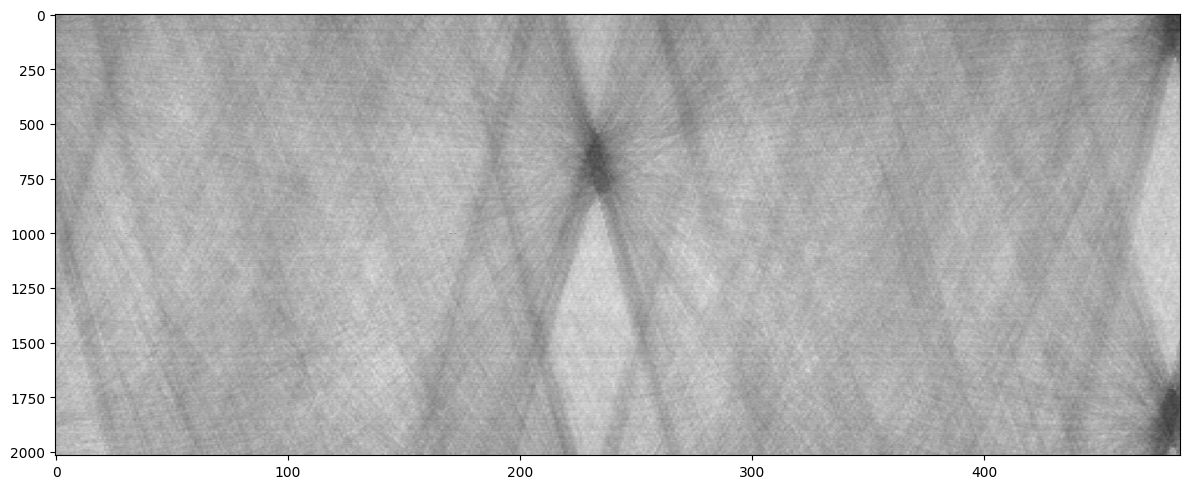

In [54]:
plt.figure(figsize=(12, 5))
plt.imshow(video_normalized[:, :, 0].numpy().T, cmap='gray', aspect='auto')
plt.tight_layout()

Analyzing slice 0
Original sinogram shape: (485, 2016)
Reconstructed sinogram shape: (485, 2016)
Angles shape: (485,)
Angle range: [5.56, 179.85] degrees
Transposed sinogram shapes for iradon: (2016, 485)
Performing FBP reconstruction on original sinogram...
Performing FBP reconstruction on compressed sinogram...
FBP reconstruction shapes: (2016, 2016), (2016, 2016)

FBP Reconstruction PSNR for slice 0: 50.19 dB


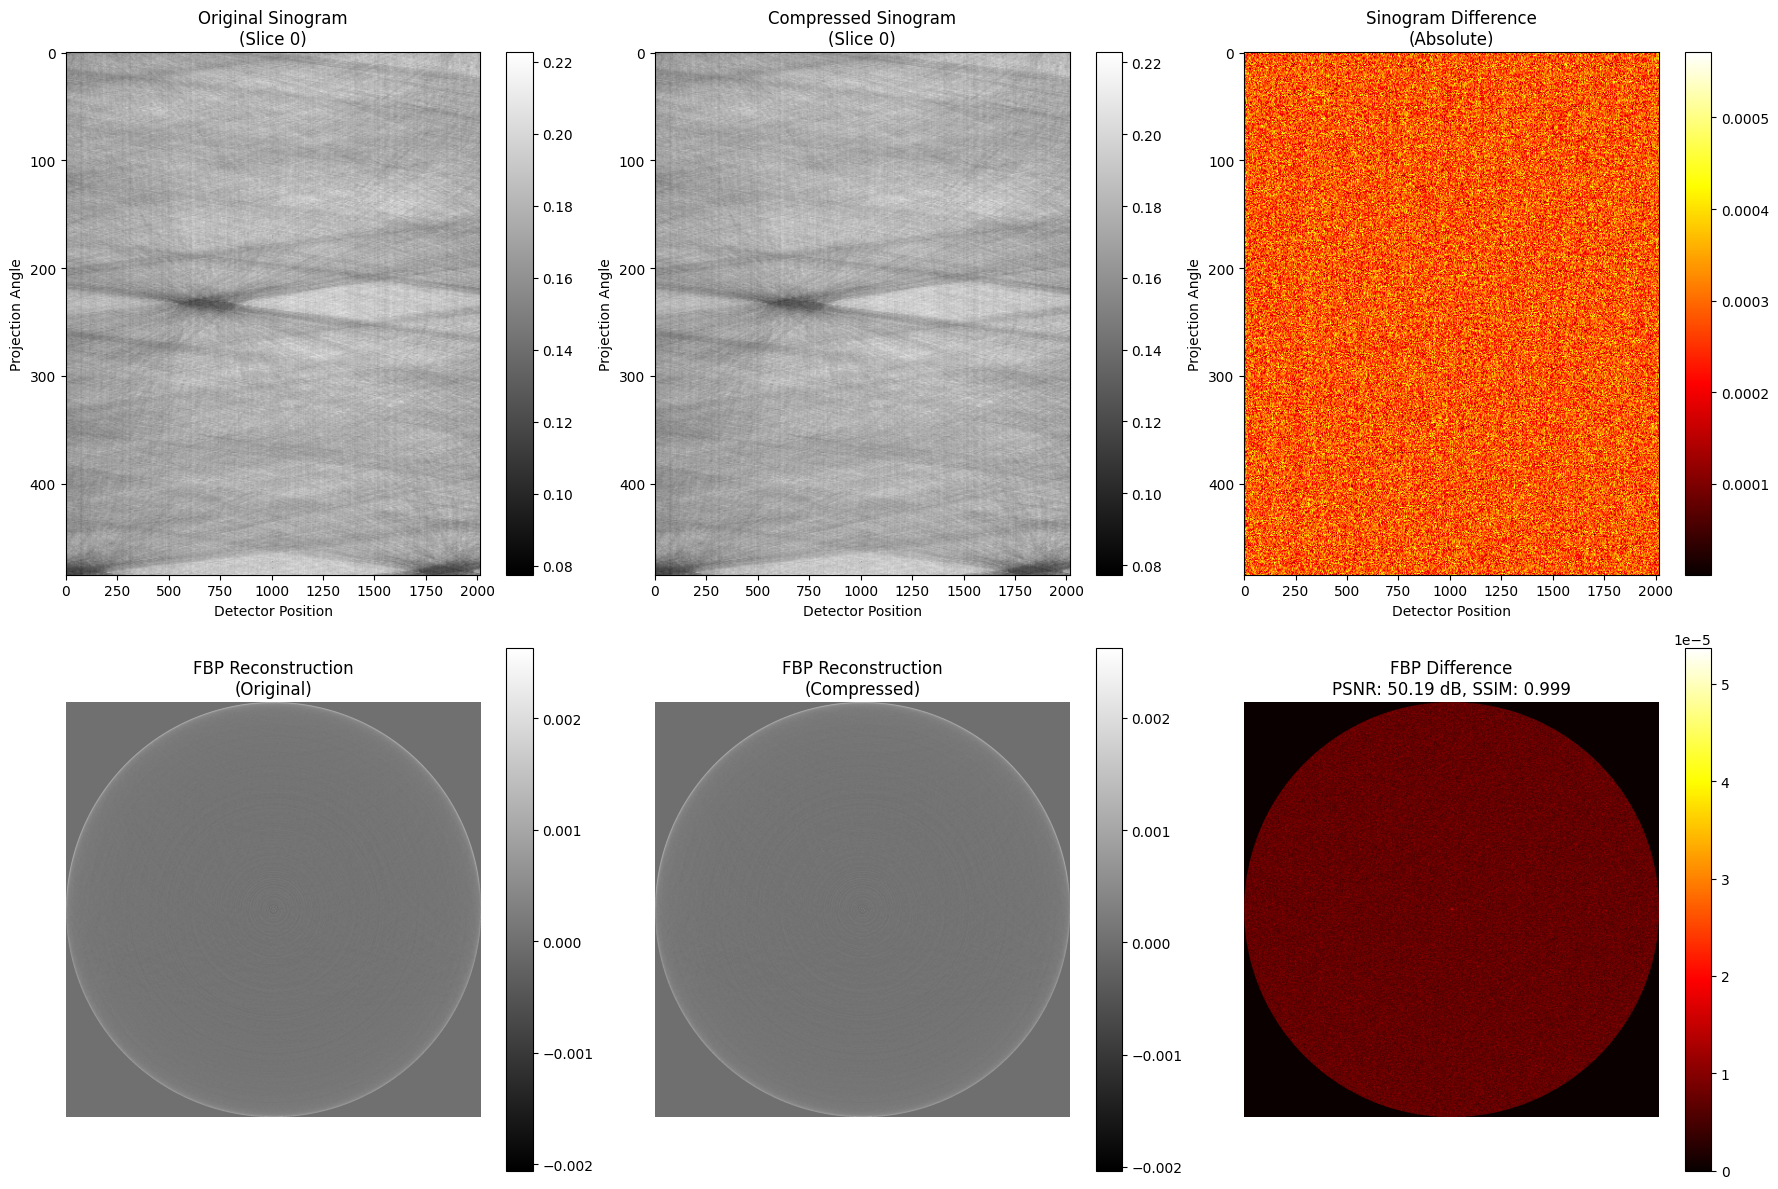


Detailed Quality Metrics for Slice 0:
  PSNR: 50.19 dB
  MSE: 0.000000
  MAE: 0.000006
  SSIM: 0.998702
  Cross-Correlation: 0.998524
  Max FBP difference: 0.000054
  Mean sinogram difference: 0.000284


In [18]:
# Test the function with the previous example
slice_idx = 0
result = compute_slice_fbp_reconstruction(slice_idx, video_normalized.transpose(-1, -2), reconstructed_video.transpose(-1, -2), volume_angles.numpy(), visualize=True)

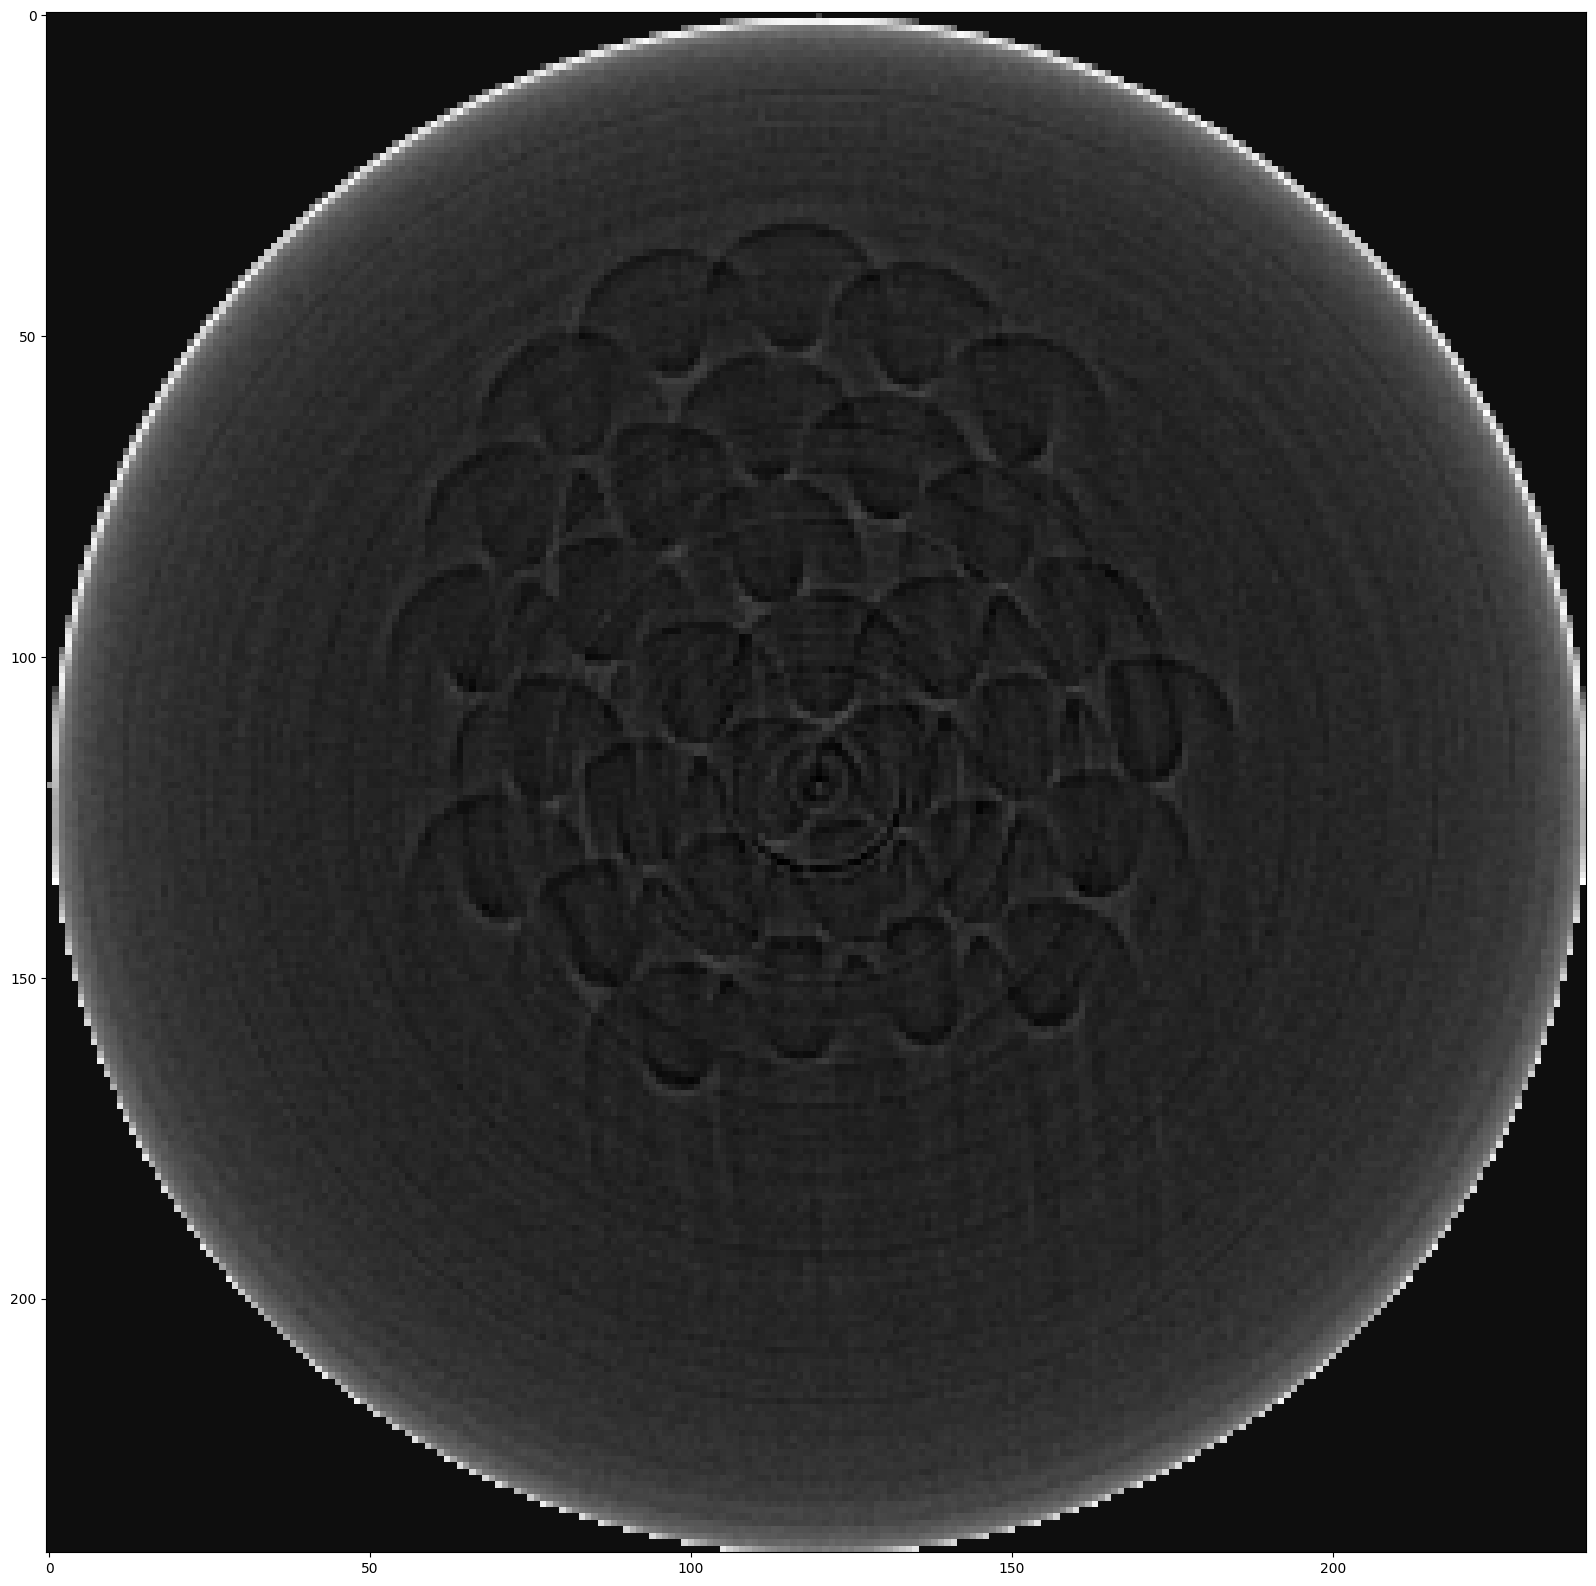

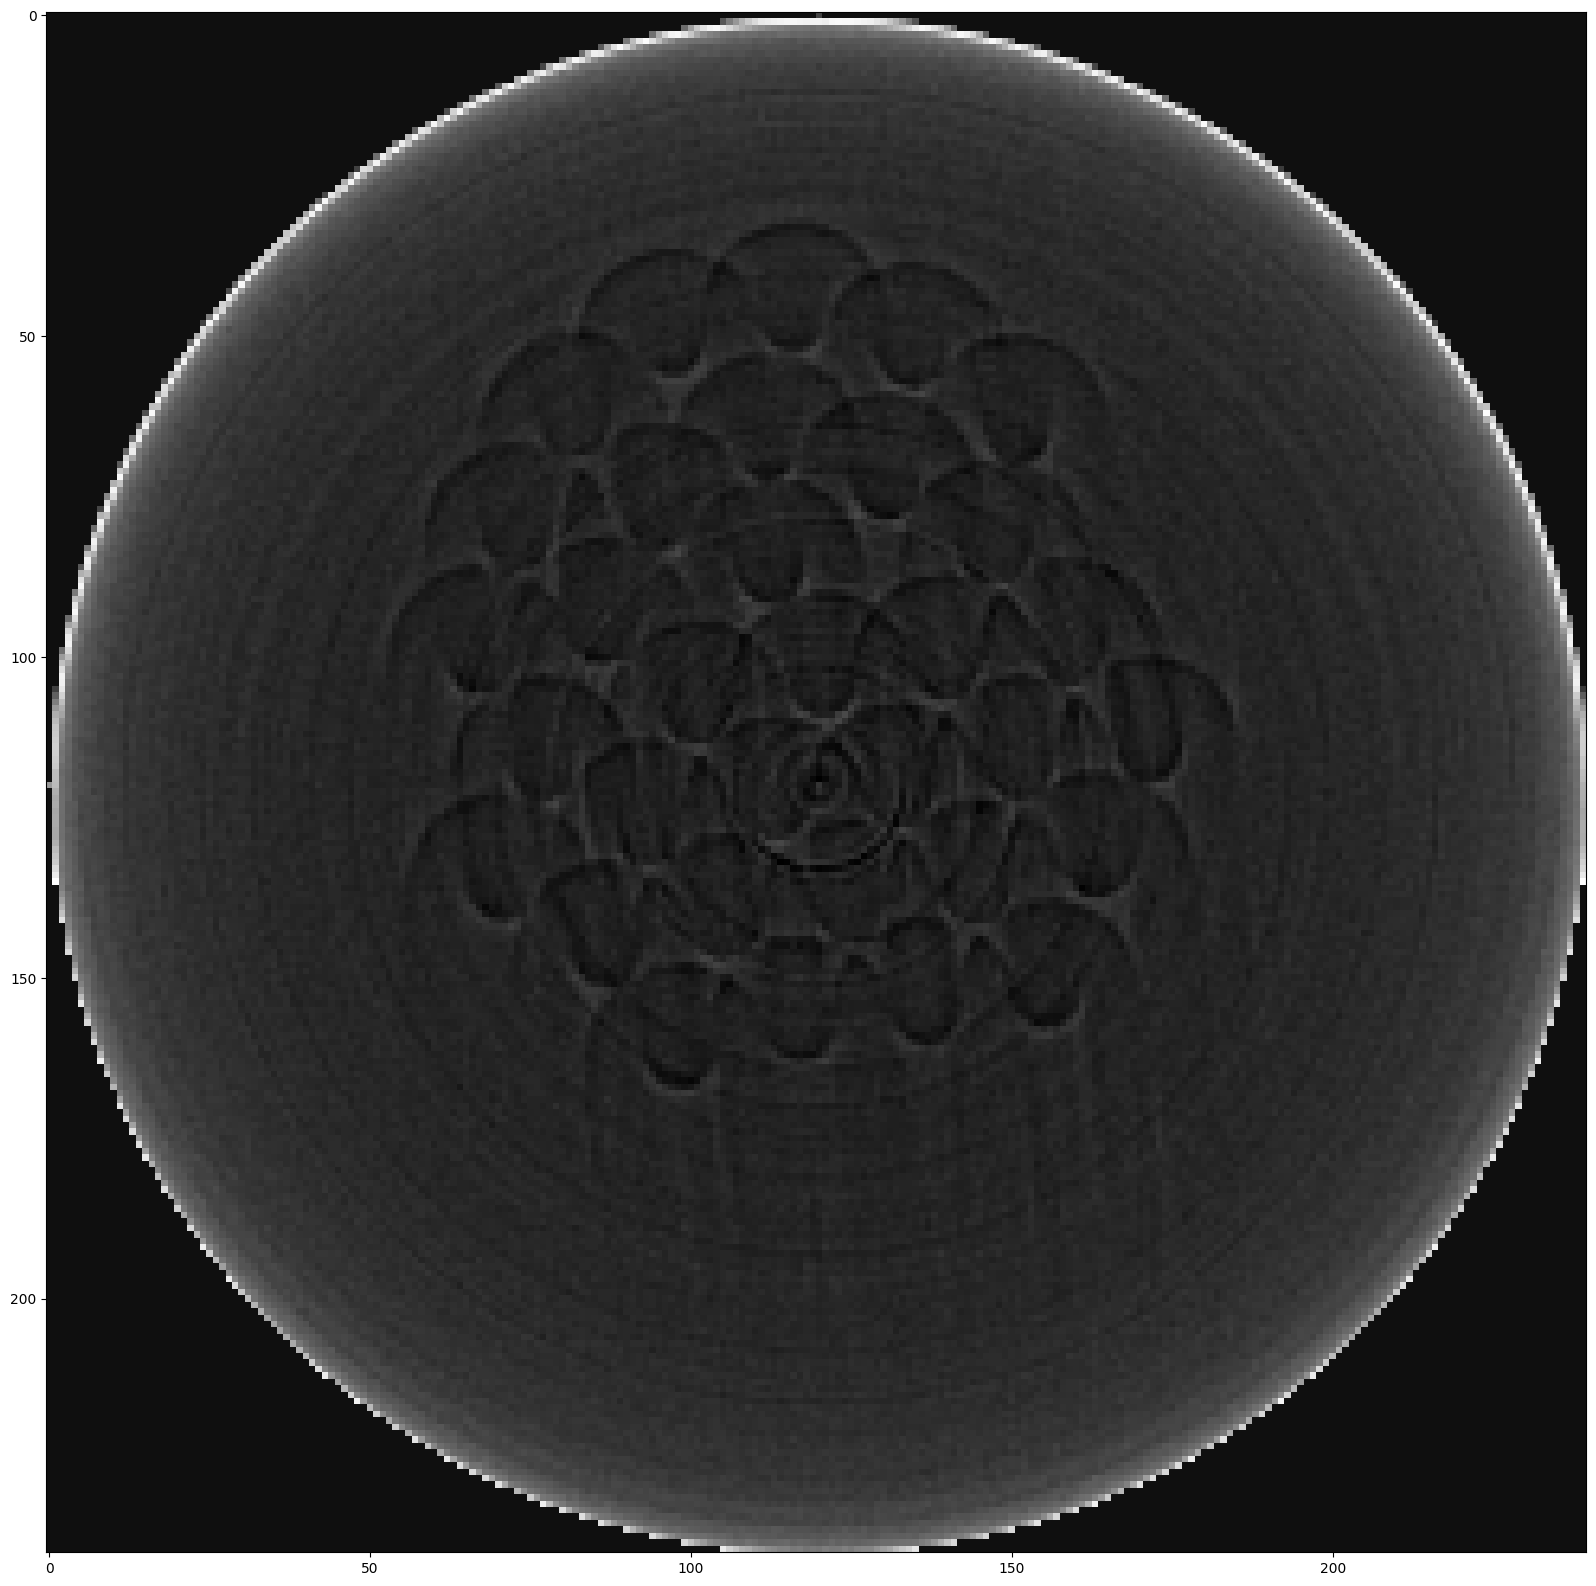

In [120]:
# Original FBP reconstruction
plt.figure(figsize=(20, 20))
plt.imshow(result["fbp_original"], cmap='gray')

# Compressed FBP reconstruction
plt.figure(figsize=(20, 20))
plt.imshow(result["fbp_reconstructed"], cmap='gray')

# Bitshuffle comparison

In [25]:
data_path = Path('../data/recon_vol_05.h5')

In [26]:
# Create bitshuffle compressed copy of the H5 file
print("🗜️ Creating Bitshuffle Compressed Copy of H5 File")
print("=" * 60)

# Install hdf5plugin if not already available
try:
    import hdf5plugin
    print("✅ hdf5plugin already available")
except ImportError:
    print("📦 Installing hdf5plugin for bitshuffle compression...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "hdf5plugin"])
    import hdf5plugin
    print("✅ hdf5plugin installed successfully")

# Create output path with bitshuffle suffix
input_h5_path = data_path
output_bitshuffle_path = data_path.parent / (data_path.stem + '_bitshuffle.h5')

print(f"📂 Source H5 file: {input_h5_path}")
print(f"📂 Output H5 file: {output_bitshuffle_path}")

try:
    # Check if output file already exists
    if output_bitshuffle_path.exists():
        print(f"⚠️  Output file already exists. Removing it...")
        output_bitshuffle_path.unlink()
    
    # Open source file and create compressed copy
    with h5py.File(input_h5_path, 'r') as source_file:
        print(f"📊 Source file info:")
        print(f"   File size: {input_h5_path.stat().st_size / 1e6:.2f} MB")
        
        # Get source data info
        if 'exchange/data' in source_file:
            source_data = source_file['exchange/data']
            print(f"   Data shape: {source_data.shape}")
            print(f"   Data type: {source_data.dtype}")
            print(f"   Current compression: {source_data.compression}")
            print(f"   Current compression opts: {source_data.compression_opts}")
        
        with h5py.File(output_bitshuffle_path, 'w') as target_file:
            print(f"\n💾 Creating bitshuffle compressed copy...")
            
            def copy_with_bitshuffle(name, obj):
                """Recursively copy all items with bitshuffle compression for datasets"""
                if isinstance(obj, h5py.Group):
                    # Create group in target
                    target_group = target_file.create_group(name)
                    
                    # Copy group attributes
                    for attr_name, attr_val in obj.attrs.items():
                        target_group.attrs[attr_name] = attr_val
                    
                    print(f"   📁 Created group: {name}")
                
                elif isinstance(obj, h5py.Dataset):
                    # Determine compression settings based on dataset size
                    dataset_size = obj.size
                    
                    if dataset_size > 1000:  # Apply compression to larger datasets
                        # Bitshuffle with LZ4 compression (maximum compression)
                        compression_kwargs = {
                            'compression': 32008,  # Bitshuffle filter ID
                            'compression_opts': (0, 2),  # (block_size=0 for auto, LZ4 compression)
                            'shuffle': False,  # Don't use HDF5 shuffle (bitshuffle handles this)
                            'fletcher32': True,  # Add checksum for data integrity
                            'chunks': True  # Enable chunking for compression
                        }
                        
                        # For very large datasets, optimize chunk size
                        if dataset_size > 1e6:
                            # Calculate optimal chunk size (aim for ~1MB chunks)
                            element_size = obj.dtype.itemsize
                            target_chunk_size = 1024 * 1024  # 1MB
                            elements_per_chunk = target_chunk_size // element_size
                            
                            if len(obj.shape) == 3:  # 3D data like (frames, height, width)
                                # Chunk along the first dimension (frames)
                                chunk_frames = min(max(1, elements_per_chunk // (obj.shape[1] * obj.shape[2])), obj.shape[0])
                                compression_kwargs['chunks'] = (chunk_frames, obj.shape[1], obj.shape[2])
                            elif len(obj.shape) == 2:  # 2D data
                                # Auto-chunking for 2D data
                                compression_kwargs['chunks'] = True
                        
                        print(f"   📄 Compressing dataset: {name}")
                        print(f"      Original size: {dataset_size:,} elements")
                        print(f"      Compression: Bitshuffle + LZ4")
                        if 'chunks' in compression_kwargs and compression_kwargs['chunks'] != True:
                            print(f"      Chunk size: {compression_kwargs['chunks']}")
                    
                    else:
                        # Small datasets - minimal or no compression
                        compression_kwargs = {}
                        print(f"   📄 Copying small dataset: {name} (no compression)")
                    
                    # Create dataset with compression
                    target_dataset = target_file.create_dataset(
                        name,
                        data=obj[...],
                        dtype=obj.dtype,
                        **compression_kwargs
                    )
                    
                    # Copy dataset attributes
                    for attr_name, attr_val in obj.attrs.items():
                        target_dataset.attrs[attr_name] = attr_val
                    
                    # Report compression info for large datasets
                    if dataset_size > 1000:
                        original_size = obj.size * obj.dtype.itemsize
                        compressed_size = target_dataset.id.get_storage_size()
                        if compressed_size > 0:
                            compression_ratio_bs = original_size / compressed_size
                            print(f"      Size reduction: {original_size/1e6:.2f} MB → {compressed_size/1e6:.2f} MB")
                            print(f"      Compression ratio: {compression_ratio_bs:.1f}:1")
                        else:
                            print(f"      Size: {original_size/1e6:.2f} MB (compression pending)")
            
            # Copy all items
            print(f"📋 Copying file structure with bitshuffle compression...")
            source_file.visititems(copy_with_bitshuffle)
            
            # Copy root attributes
            for attr_name, attr_val in source_file.attrs.items():
                target_file.attrs[attr_name] = attr_val
    
    # Verify the created file
    print(f"\n🔍 Verifying compressed file...")
    with h5py.File(output_bitshuffle_path, 'r') as verify_file:
        if 'exchange/data' in verify_file:
            compressed_data = verify_file['exchange/data']
            
            # File size comparison
            original_size = input_h5_path.stat().st_size
            compressed_size = output_bitshuffle_path.stat().st_size
            compression_ratio_bs = original_size / compressed_size
            print("compression_ratio_bs", compression_ratio_bs)
            space_savings = (1 - compressed_size / original_size) * 100
            
            print(f"✅ Verification successful!")
            print(f"📊 Compression Results:")
            print(f"   Original file size: {original_size / 1e6:.2f} MB")
            print(f"   Compressed file size: {compressed_size / 1e6:.2f} MB")
            print(f"   Compression ratio: {compression_ratio_bs:.1f}:1")
            print(f"   Space savings: {space_savings:.1f}%")
            print(f"   Data shape preserved: {compressed_data.shape}")
            print(f"   Data type preserved: {compressed_data.dtype}")
            print(f"   Compression filter: {compressed_data.compression}")
            print(f"   Compression options: {compressed_data.compression_opts}")
            
            # Quick data integrity check
            with h5py.File(input_h5_path, 'r') as orig_file:
                orig_data = orig_file['exchange/data']
                
                # Compare a small sample of data
                sample_size = min(10, orig_data.shape[0])
                if sample_size > 0:
                    orig_sample = orig_data[:sample_size]
                    comp_sample = compressed_data[:sample_size]
                    
                    if np.array_equal(orig_sample, comp_sample):
                        print(f"   ✅ Data integrity verified (sample of {sample_size} frames)")
                    else:
                        print(f"   ❌ Data integrity check failed!")
                        print(f"      Original sample range: [{orig_sample.min()}, {orig_sample.max()}]")
                        print(f"      Compressed sample range: [{comp_sample.min()}, {comp_sample.max()}]")
        else:
            print(f"❌ Verification failed - no exchange/data found")
    
    print(f"\n✅ Successfully created bitshuffle compressed H5 file!")
    print(f"📁 Saved to: {output_bitshuffle_path}")
    print(f"🗜️ Applied bitshuffle compression with LZ4 for maximum compression")
    print(f"💾 Achieved {compression_ratio_bs:.1f}:1 compression ratio")

except Exception as e:
    print(f"❌ Error creating bitshuffle compressed file: {e}")
    import traceback
    traceback.print_exc()

🗜️ Creating Bitshuffle Compressed Copy of H5 File
✅ hdf5plugin already available
📂 Source H5 file: ../data/recon_vol_05.h5
📂 Output H5 file: ../data/recon_vol_05_bitshuffle.h5
📊 Source file info:
   File size: 29262.65 MB

💾 Creating bitshuffle compressed copy...
📋 Copying file structure with bitshuffle compression...
   📄 Compressing dataset: recon
      Original size: 7,315,660,800 elements
      Compression: Bitshuffle + LZ4
      Chunk size: (1, 2016, 2016)
      Size reduction: 29262.64 MB → 21127.29 MB
      Compression ratio: 1.4:1

🔍 Verifying compressed file...
❌ Verification failed - no exchange/data found

✅ Successfully created bitshuffle compressed H5 file!
📁 Saved to: ../data/recon_vol_05_bitshuffle.h5
🗜️ Applied bitshuffle compression with LZ4 for maximum compression
❌ Error creating bitshuffle compressed file: name 'compression_ratio_bs' is not defined


Traceback (most recent call last):
  File "/var/folders/tz/dk16058s17q23bj28chlys680000gn/T/ipykernel_77877/4236547446.py", line 175, in <module>
    print(f"💾 Achieved {compression_ratio_bs:.1f}:1 compression ratio")
NameError: name 'compression_ratio_bs' is not defined


# Noise Removal

In [ ]:
# Apply Denoising to Video Frames
print("🧹 Applying Denoising to Video Frames")
print("=" * 50)

import cv2
from tqdm.auto import tqdm

if 'video_normalized' in locals() and video_normalized is not None:
    print(f"📊 Original video shape: {video_normalized.shape}")
    print(f"📊 Processing {video_normalized.shape[0]} frames...")
    
    # Create tensor to store denoised frames
    video_denoised = torch.zeros_like(video_normalized)
    
    # Denoising parameters for minimal Gaussian noise
    h = 2          # Filter strength. For minimal noise, use low value (3-6)
    template_window_size = 5   # Size of template patch (should be odd)
    search_window_size = 15    # Size of search window (should be odd)
    
    print(f"🔧 Denoising parameters:")
    print(f"   Filter strength (h): {h}")
    print(f"   Template window size: {template_window_size}")
    print(f"   Search window size: {search_window_size}")
    
    # Process each frame
    for i in tqdm(range(video_normalized.shape[0]), desc="Denoising frames"):
        # Convert to numpy and ensure correct data type for OpenCV
        frame = video_normalized[i].numpy().astype(np.float32)
        
        # Normalize to 0-255 range for OpenCV
        frame_uint8 = (frame * 255).astype(np.uint8)
        
        # Apply Non-local Means Denoising
        denoised_frame = cv2.fastNlMeansDenoising(
            frame_uint8,
            None,
            h=h,
            templateWindowSize=template_window_size,
            searchWindowSize=search_window_size
        )
        
        # Convert back to normalized float format
        denoised_normalized = denoised_frame.astype(np.float32) / 255.0
        
        # Store in tensor
        video_denoised[i] = torch.from_numpy(denoised_normalized)
    
    print(f"✅ Denoising completed!")
    print(f"📊 Denoised video shape: {video_denoised.shape}")
    print(f"📊 Denoised video range: [{video_denoised.min():.6f}, {video_denoised.max():.6f}]")
    
    # # Calculate noise reduction metrics
    # print(f"\n📈 Noise Reduction Analysis:")
    
    # # Calculate difference between original and denoised
    # noise_removed = video_normalized - video_denoised
    
    # print(f"   Mean noise removed: {noise_removed.mean().item():.6f}")
    # print(f"   Std of noise removed: {noise_removed.std().item():.6f}")
    # print(f"   Max noise removed: {noise_removed.max().item():.6f}")
    # print(f"   Min noise removed: {noise_removed.min().item():.6f}")
    
    # # Calculate PSNR between original and denoised (higher is better preservation)
    # mse_denoising = torch.mean((video_normalized - video_denoised) ** 2)
    # if mse_denoising > 0:
    #     max_val = video_normalized.max()
    #     psnr_denoising = 20 * torch.log10(max_val / torch.sqrt(mse_denoising))
    #     print(f"   PSNR (original vs denoised): {psnr_denoising.item():.2f} dB")
    # else:
    #     print(f"   PSNR (original vs denoised): ∞ dB (identical)")
    
    # # Visual comparison for a few sample frames
    # print(f"\n🎨 Creating visual comparison...")
    
    # # Select frames for comparison
    # sample_frames = [0, video_normalized.shape[0]//4, video_normalized.shape[0]//2, -1]
    # sample_frames = [f for f in sample_frames if f < video_normalized.shape[0]]
    
    # fig, axes = plt.subplots(3, len(sample_frames), figsize=(5*len(sample_frames), 12))
    # if len(sample_frames) == 1:
    #     axes = axes.reshape(-1, 1)
    
    # for i, frame_idx in enumerate(sample_frames):
    #     if frame_idx < 0:
    #         frame_idx = video_normalized.shape[0] + frame_idx
            
    #     # Original frame
    #     axes[0, i].imshow(video_normalized[frame_idx].numpy(), cmap='gray')
    #     axes[0, i].set_title(f'Original Frame {frame_idx}')
    #     axes[0, i].axis('off')
        
    #     # Denoised frame
    #     axes[1, i].imshow(video_denoised[frame_idx].numpy(), cmap='gray')
    #     axes[1, i].set_title(f'Denoised Frame {frame_idx}')
    #     axes[1, i].axis('off')
        
    #     # Noise removed (difference)
    #     noise_frame = noise_removed[frame_idx].numpy()
    #     im = axes[2, i].imshow(noise_frame, cmap='coolwarm', 
    #                           vmin=-noise_removed.abs().max(), vmax=noise_removed.abs().max())
    #     axes[2, i].set_title(f'Noise Removed\n(range: [{noise_frame.min():.3f}, {noise_frame.max():.3f}])')
    #     axes[2, i].axis('off')
    #     plt.colorbar(im, ax=axes[2, i], fraction=0.046, pad=0.04)
    
    # plt.suptitle('Denoising Comparison: Non-local Means', fontsize=16, fontweight='bold')
    # plt.tight_layout()
    # plt.show()
    
    # # Option to replace video_normalized with denoised version
    # print(f"\n💡 To use the denoised version for further processing:")
    # print(f"   Run: video_normalized = video_denoised.clone()")
    # print(f"   This will replace the original with the denoised version")
    
else:
    print("❌ video_normalized not found. Please run the video loading cells first.")

🧹 Applying Denoising to Video Frames
📊 Original video shape: torch.Size([900, 2016, 1800])
📊 Processing 900 frames...
🔧 Denoising parameters:
   Filter strength (h): 2
   Template window size: 5
   Search window size: 15


Denoising frames:   0%|          | 0/900 [00:00<?, ?it/s]

✅ Denoising completed!
📊 Denoised video shape: torch.Size([900, 1800, 2016])
📊 Denoised video range: [0.000000, 1.000000]


In [ ]:
compressed_video_path = "demo_10b.mov"
encode_hevc_grayscale_10bit(video_denoised, compressed_video_path, fps=24, preset_sw="veryslow", cq_hw=100) # 100 is visually lossless
reconstructed_video = decode_hevc_grayscale_10bit(compressed_video_path, device="cpu")
print("reconstructed_video", reconstructed_video)

📤  encoding 900 × 2016×1800 frames  (grayscale 10-bit HEVC)
✓ hardware encode succeeded
